# 01 — Exploratory Data Analysis
Przegląd plików MIMIC-III: rozkłady, jakość danych, weryfikacja item IDs.

> Uruchamiaj z katalogu projektu (`THS_Prediction/`) lub upewnij się, że `config.py` jest na `sys.path`.

In [1]:
import sys
from pathlib import Path

# Dodaj katalog projektu do path (jeśli uruchamiasz z notebooks/)
PROJECT_ROOT = Path(__file__).parent.parent if '__file__' in dir() else Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

# Verify MIMIC path
assert config.MIMIC_DIR.exists(), f"MIMIC-III directory not found: {config.MIMIC_DIR}"

print("\n Available MIMIC-III files:")
print("_" * 55)
for f in sorted(config.MIMIC_DIR.glob('*.csv.gz')):
    print(f"  {f.name:40s} ({f.stat().st_size / 1024**2:>8.1f} MB)")



 Available MIMIC-III files:
_______________________________________________________
  ADMISSIONS.csv.gz                        (     2.4 MB)
  CALLOUT.csv.gz                           (     1.1 MB)
  CAREGIVERS.csv.gz                        (     0.0 MB)
  CHARTEVENTS.csv.gz                       (  4088.4 MB)
  CPTEVENTS.csv.gz                         (     4.7 MB)
  D_CPT.csv.gz                             (     0.0 MB)
  D_ICD_DIAGNOSES.csv.gz                   (     0.3 MB)
  D_ICD_PROCEDURES.csv.gz                  (     0.1 MB)
  D_ITEMS.csv.gz                           (     0.2 MB)
  D_LABITEMS.csv.gz                        (     0.0 MB)
  DATETIMEEVENTS.csv.gz                    (    52.5 MB)
  DIAGNOSES_ICD.csv.gz                     (     4.5 MB)
  DRGCODES.csv.gz                          (     1.7 MB)
  ICUSTAYS.csv.gz                          (     1.9 MB)
  INPUTEVENTS_CV.csv.gz                    (   402.6 MB)
  INPUTEVENTS_MV.csv.gz                    (   143.9 MB)
  L

## ADMISSIONS.csv

In [2]:
admissions = pd.read_csv(config.MIMIC_DIR / 'ADMISSIONS.csv.gz')
admissions.head()


,ROW_ID,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2196-04-09 10:06:00,2196-04-09 13:24:00,BENZODIAZEPINE OVERDOSE,0,1
1,22,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,MARRIED,WHITE,NaN,NaN,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,0,1
2,23,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,NaN,NaN,BRAIN MASS,0,1
3,24,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME,Private,NaN,PROTESTANT QUAKER,SINGLE,WHITE,NaN,NaN,INTERIOR MYOCARDIAL INFARCTION,0,1
4,25,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2160-11-02 01:01:00,2160-11-02 04:27:00,ACUTE CORONARY SYNDROME,0,1


In [3]:
print(f"Total records:     {len(admissions):,}")
print(f"Unique HADM_ID:    {admissions['HADM_ID'].nunique():,}")
print(f"Unique SUBJECT_ID: {admissions['SUBJECT_ID'].nunique():,}")
print(f"Duplicate HADM_ID: {len(admissions) - admissions['HADM_ID'].nunique()}")

readmissions = admissions.groupby('SUBJECT_ID').size()
print(f"\nPatients with 1 admission:  {(readmissions == 1).sum():,}")
print(f"Patients with 2+ admissions: {(readmissions >= 2).sum():,}")
print(f"Max admissions (1 patient):  {readmissions.max()}")


Total records:     58,976
Unique HADM_ID:    58,976
Unique SUBJECT_ID: 46,520
Duplicate HADM_ID: 0

Patients with 1 admission:  38,983
Patients with 2+ admissions: 7,537
Max admissions (1 patient):  42


In [4]:
admissions_eda = admissions.copy()
admissions_eda['ADMITTIME'] = pd.to_datetime(admissions_eda['ADMITTIME'])
admissions_eda['DISCHTIME']  = pd.to_datetime(admissions_eda['DISCHTIME'])
admissions_eda['LOS_DAYS']   = (admissions_eda['DISCHTIME'] - admissions_eda['ADMITTIME']).dt.total_seconds() / 86400

print("LOS Statistics:")
print(admissions_eda['LOS_DAYS'].describe())

neg_los = (admissions_eda['LOS_DAYS'] < 0).sum()
ext_los = (admissions_eda['LOS_DAYS'] > 100).sum()
print(f"\nData Quality:")
print(f"  Negative LOS (<0 days):  {neg_los}  → filtrowane w preprocessing")
print(f"  Extreme LOS (>100 days): {ext_los}")


LOS Statistics:
count   58976.00
mean       10.13
std        12.46
min        -0.95
25%         3.74
50%         6.47
75%        11.80
max       294.66
Name: LOS_DAYS, dtype: float64

Data Quality:
  Negative LOS (<0 days):  98  → filtrowane w preprocessing
  Extreme LOS (>100 days): 155


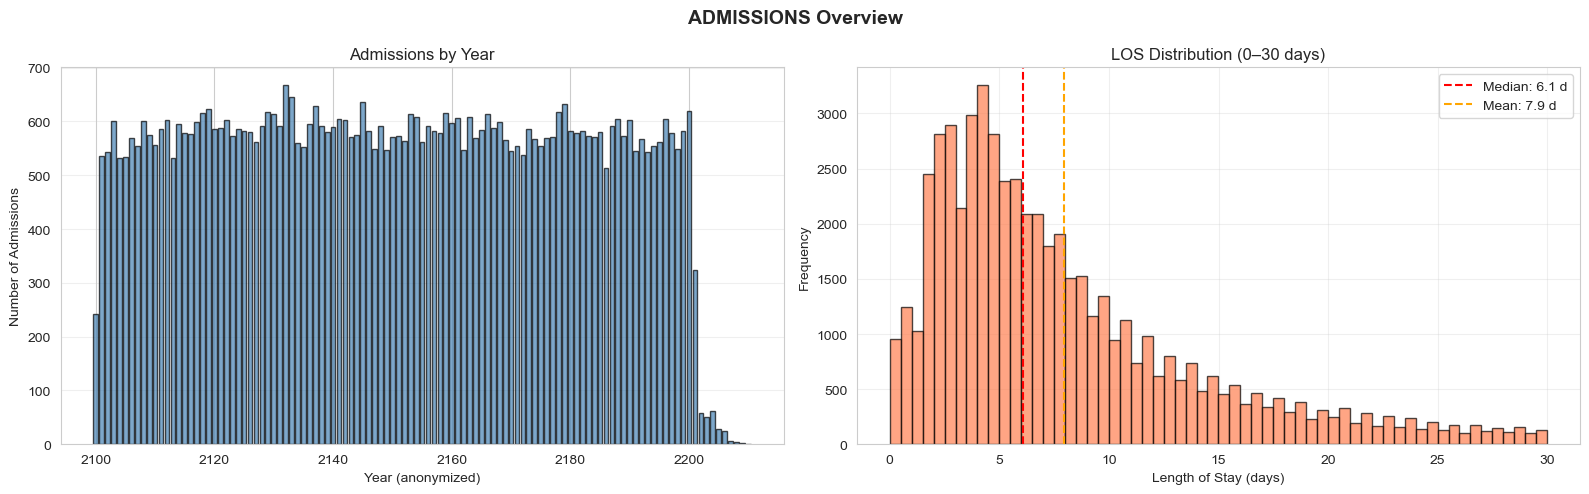

In [5]:
admissions_eda['YEAR'] = admissions_eda['ADMITTIME'].dt.year
yearly_counts = admissions_eda['YEAR'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ADMISSIONS Overview', fontsize=14, fontweight='bold')

# Admissions by year
ax = axes[0]
ax.bar(yearly_counts.index, yearly_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Year (anonymized)')
ax.set_ylabel('Number of Admissions')
ax.set_title('Admissions by Year')
ax.grid(True, alpha=0.3, axis='y')

# LOS distribution (0-30 days)
ax = axes[1]
los_filtered = admissions_eda[admissions_eda['LOS_DAYS'].between(0, 30)]['LOS_DAYS']
ax.hist(los_filtered, bins=60, color='coral', alpha=0.7, edgecolor='black')
ax.axvline(los_filtered.median(), color='red', ls='--', label=f'Median: {los_filtered.median():.1f} d')
ax.axvline(los_filtered.mean(),   color='orange', ls='--', label=f'Mean: {los_filtered.mean():.1f} d')
ax.set_xlabel('Length of Stay (days)')
ax.set_ylabel('Frequency')
ax.set_title('LOS Distribution (0–30 days)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / '01_admissions_overview.png')
plt.show()


## PATIENTS.csv

In [6]:
patients = pd.read_csv(config.MIMIC_DIR / 'PATIENTS.csv.gz')
print(f"Records: {len(patients):,} | Unique SUBJECT_ID: {patients['SUBJECT_ID'].nunique():,}")
print(f"Gender: {patients['GENDER'].value_counts().to_dict()}")

missing = patients.isnull().sum()
print("\nMissing values:")
print(missing[missing > 0].to_string())


Records: 46,520 | Unique SUBJECT_ID: 46,520
Gender: {'M': 26121, 'F': 20399}

Missing values:
DOD         30761
DOD_HOSP    36546
DOD_SSN     33142


Age Statistics (capped at 90 per MIMIC anonymization):
count   46520.00
mean       52.89
std        28.77
min         0.00
25%        38.00
50%        60.00
75%        75.00
max        90.00
Name: AGE_ACTUAL, dtype: float64


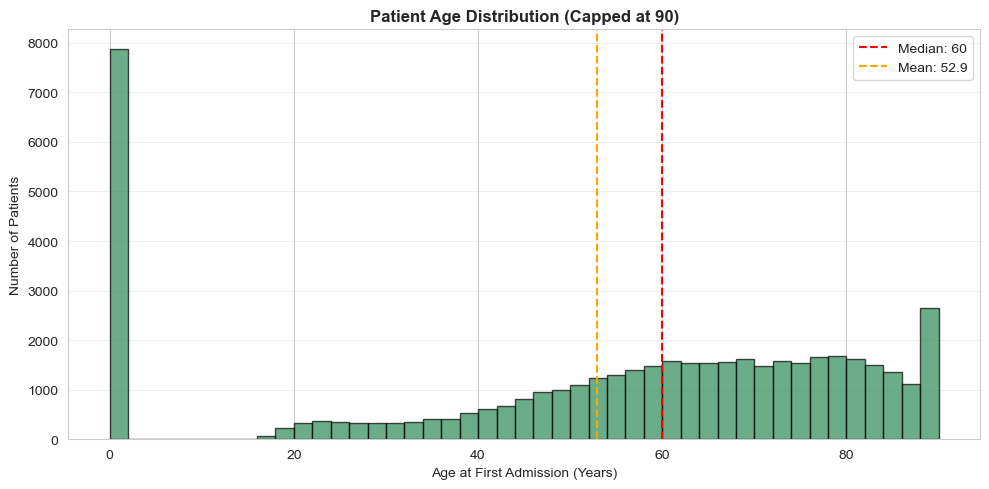

In [7]:
patients_eda = patients.copy()
patients_eda['DOB'] = pd.to_datetime(patients_eda['DOB'])

first_admissions = admissions.copy()
first_admissions['ADMITTIME'] = pd.to_datetime(first_admissions['ADMITTIME'])
first_adm = first_admissions.sort_values('ADMITTIME').groupby('SUBJECT_ID')['ADMITTIME'].first().reset_index()

patients_age = pd.merge(patients_eda, first_adm, on='SUBJECT_ID', how='inner')
patients_age['AGE_YEARS']  = patients_age['ADMITTIME'].dt.year - patients_age['DOB'].dt.year
patients_age['AGE_ACTUAL'] = patients_age['AGE_YEARS'].apply(lambda x: 90 if x > 89 else x)

print("Age Statistics (capped at 90 per MIMIC anonymization):")
print(patients_age['AGE_ACTUAL'].describe())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(patients_age['AGE_ACTUAL'], bins=45, range=(0, 90), color='seagreen', alpha=0.7, edgecolor='black')
ax.axvline(patients_age['AGE_ACTUAL'].median(), color='red', ls='--',
           label=f"Median: {patients_age['AGE_ACTUAL'].median():.0f}")
ax.axvline(patients_age['AGE_ACTUAL'].mean(),   color='orange', ls='--',
           label=f"Mean: {patients_age['AGE_ACTUAL'].mean():.1f}")
ax.set_xlabel('Age at First Admission (Years)')
ax.set_ylabel('Number of Patients')
ax.set_title('Patient Age Distribution (Capped at 90)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / '02_patients_age.png')
plt.show()

del patients_eda, first_adm, patients_age


## DIAGNOSES_ICD.csv

In [8]:
diagnoses = pd.read_csv(config.MIMIC_DIR / 'DIAGNOSES_ICD.csv.gz')
print(f"Records: {len(diagnoses):,}")
print(f"Unique HADM_ID:  {diagnoses['HADM_ID'].nunique():,}")
print(f"Unique ICD9 codes: {diagnoses['ICD9_CODE'].nunique():,}")

diag_per_adm = diagnoses.groupby('HADM_ID').size()
print(f"\nDiagnoses per admission: mean={diag_per_adm.mean():.1f}, median={diag_per_adm.median():.0f}")


Records: 651,047
Unique HADM_ID:  58,976
Unique ICD9 codes: 6,984

Diagnoses per admission: mean=11.0, median=9


In [9]:
# Trauma prevalence
trauma_mask = diagnoses['ICD9_CODE'].str.match(config.TRAUMA_PATTERN, na=False)
trauma_diag = diagnoses[trauma_mask]

n_trauma_adm = trauma_diag['HADM_ID'].nunique()
n_total_adm  = diagnoses['HADM_ID'].nunique()

print(f"Trauma diagnosis records: {len(trauma_diag):,}")
print(f"Trauma admissions:        {n_trauma_adm:,} ({n_trauma_adm/n_total_adm*100:.1f}% of all)")
print(f"\nTop 10 trauma ICD-9 codes:")
print(trauma_diag['ICD9_CODE'].value_counts().head(10).to_string())


Trauma diagnosis records: 34,208
Trauma admissions:        13,643 (23.1% of all)

Top 10 trauma ICD-9 codes:
ICD9_CODE
E8798    1502
E8788    1350
E8782    1211
E8497    1039
E8889     997
E8781     707
E8859     704
E8809     545
E8790     463
E8780     430


Exclusion analysis:
  septic_shock: 4,085 admissions
  cardiogenic_shock: 1,154 admissions
  anaphylactic_shock: 75 admissions

Trauma admissions excluded: 1,154
Estimated final cohort:     12,489


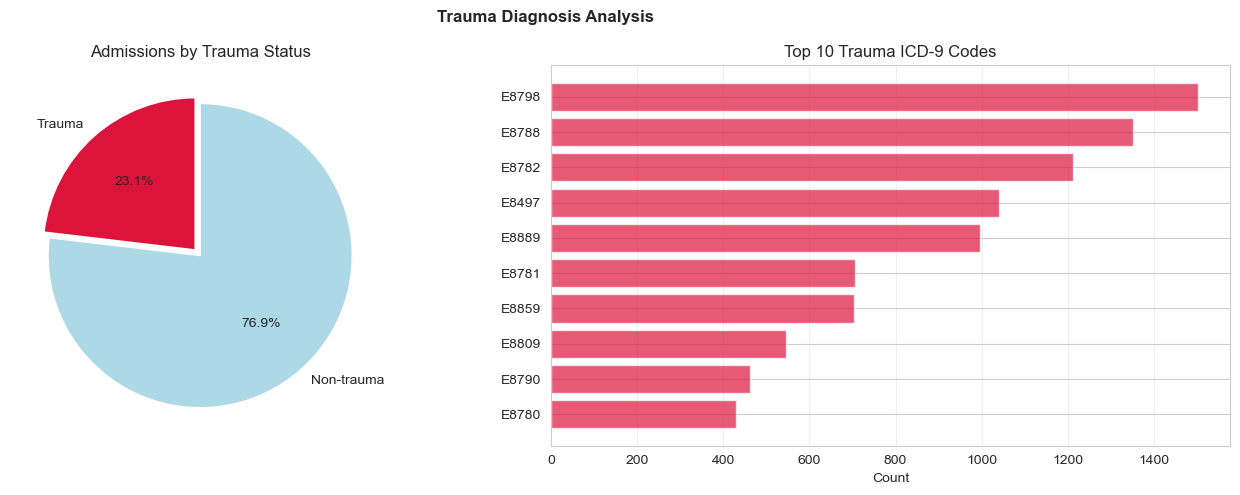

In [10]:
# Exclusion analysis (septic / cardiogenic / anaphylactic shock)
exclusion_adm = set()
print("Exclusion analysis:")
for category, codes in config.EXCLUSION_ICD9.items():
    matches    = diagnoses[diagnoses['ICD9_CODE'].isin(codes)]
    unique_adm = matches['HADM_ID'].unique()
    exclusion_adm.update(unique_adm)
    print(f"  {category}: {len(unique_adm):,} admissions")

trauma_adm_set   = set(trauma_diag['HADM_ID'].unique())
overlap          = trauma_adm_set & exclusion_adm
final_cohort_est = len(trauma_adm_set - exclusion_adm)

print(f"\nTrauma admissions excluded: {len(overlap):,}")
print(f"Estimated final cohort:     {final_cohort_est:,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Trauma Diagnosis Analysis', fontweight='bold')

axes[0].pie([n_trauma_adm, n_total_adm - n_trauma_adm],
            labels=['Trauma', 'Non-trauma'], colors=['crimson', 'lightblue'],
            autopct='%1.1f%%', explode=(0.05, 0), startangle=90)
axes[0].set_title('Admissions by Trauma Status')

top10 = trauma_diag['ICD9_CODE'].value_counts().head(10)
axes[1].barh(range(10), top10.values, color='crimson', alpha=0.7)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(top10.index)
axes[1].set_xlabel('Count')
axes[1].set_title('Top 10 Trauma ICD-9 Codes')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / '03_diagnoses_trauma.png')
plt.show()


## CHARTEVENTS.csv

Duży plik (~4 GB). Wczytujemy próbkę 3M wierszy wyłącznie dla EDA.

In [11]:
chartevents_sample = pd.read_csv(config.MIMIC_DIR / 'CHARTEVENTS.csv.gz', nrows=3_000_000)
print(f"Sample shape:       {chartevents_sample.shape}")
print(f"Unique HADM_ID:     {chartevents_sample['HADM_ID'].nunique():,}")
print(f"Unique ItemIDs:     {chartevents_sample['ITEMID'].nunique():,}")


Sample shape:       (3000000, 15)
Unique HADM_ID:     2,144
Unique ItemIDs:     444


In [12]:
# Analiza zakresów i outlierów na próbce
outlier_stats = []
for vital, (lo, hi) in config.VITAL_RANGES.items():
    ids  = config.ITEMIDS[vital]
    data = chartevents_sample[chartevents_sample['ITEMID'].isin(ids)]['VALUENUM'].dropna()
    if len(data) == 0:
        continue
    n_out = ((data < lo) | (data > hi)).sum()
    outlier_stats.append({
        'Vital': vital, 'Count': len(data),
        'Min': data.min(), 'Max': data.max(),
        'Range': f"{lo}–{hi}",
        'Outliers': n_out, 'Outlier_%': round(n_out / len(data) * 100, 2)
    })

pd.DataFrame(outlier_stats).set_index('Vital')


,Count,Min,Max,Range,Outliers,Outlier_%
Vital,,,,,,
HR,227647,-88.00,6632.00,20–200,105,0.05
SBP,208377,0.00,141146.04,30–250,60,0.03
DBP,208309,0.00,114108.98,20–150,435,0.21
MBP,214507,-32.00,8348.00,30–200,980,0.46
RESP,272805,0.00,600.00,5–80,2125,0.78
TEMP,46096,0.00,998.70,25–42,42311,91.79
SpO2,220640,0.00,9877.00,50–100,85,0.04


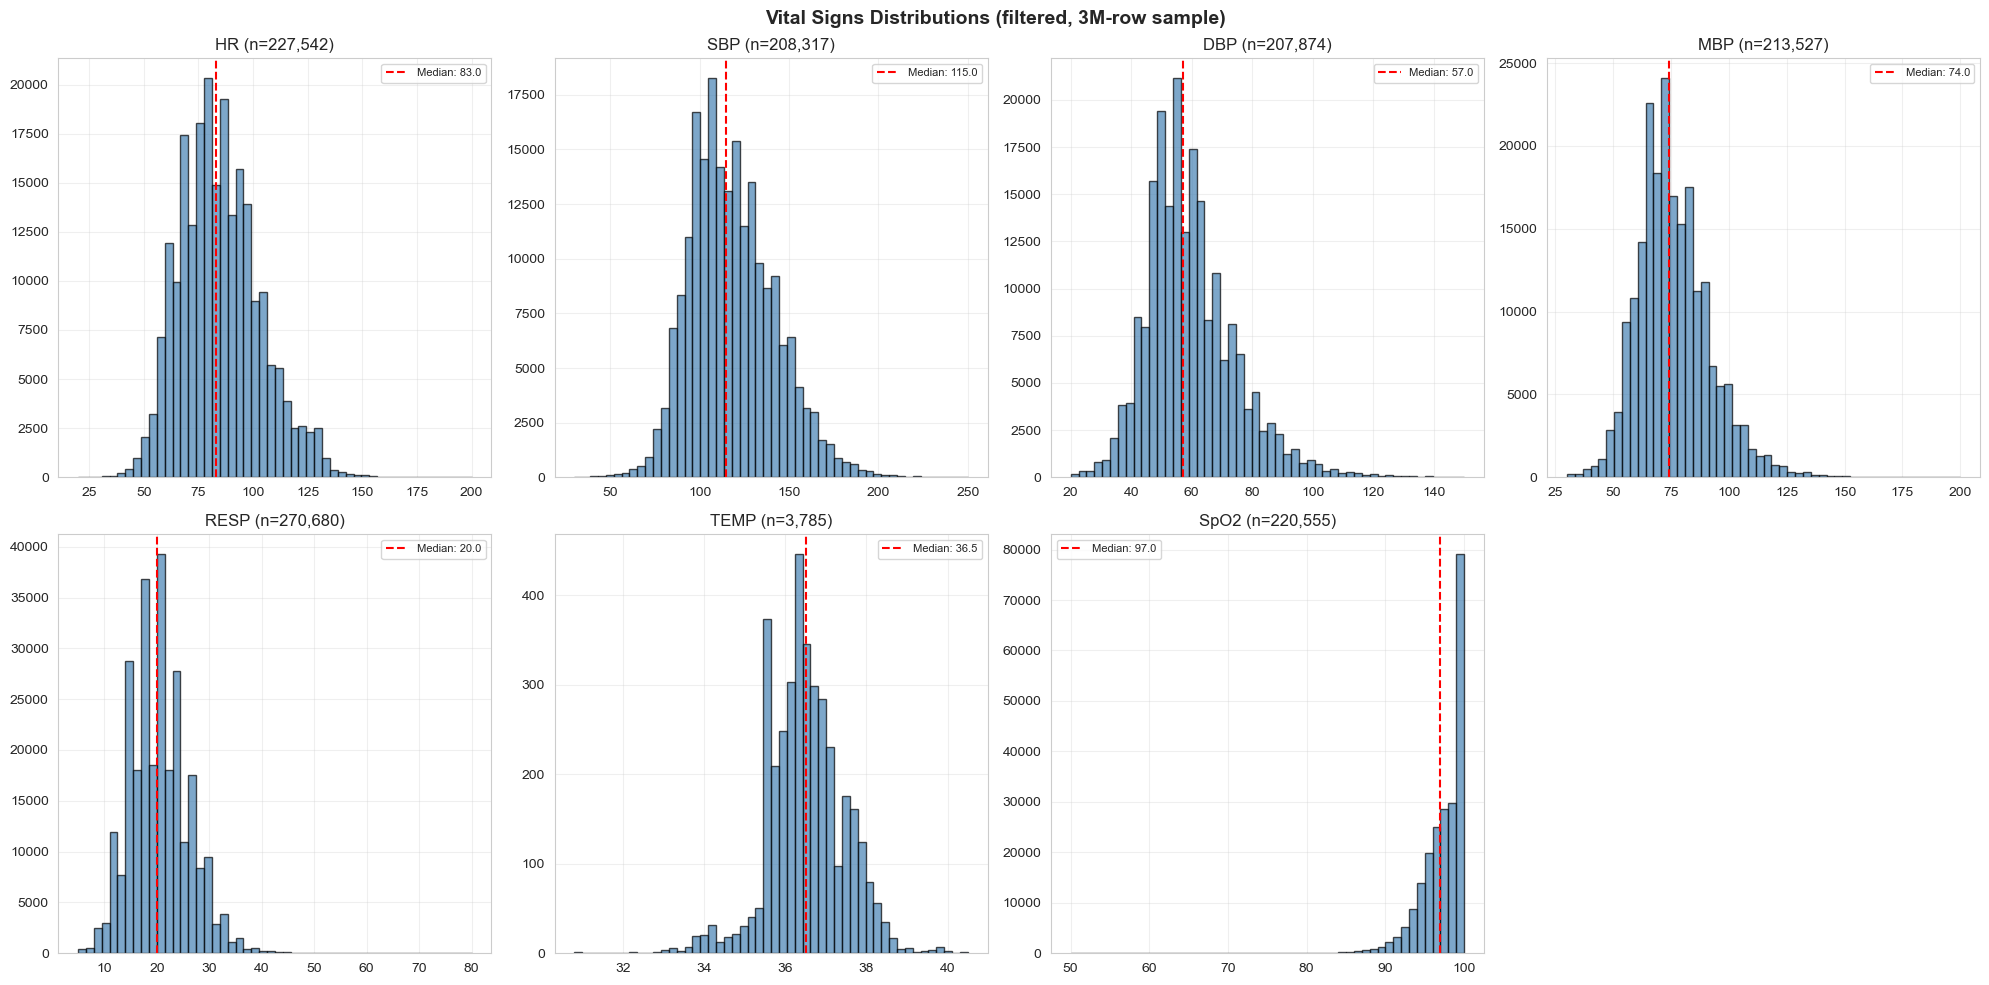

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Vital Signs Distributions (filtered, 3M-row sample)', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for idx, (vital, (lo, hi)) in enumerate(config.VITAL_RANGES.items()):
    ax   = axes_flat[idx]
    ids  = config.ITEMIDS[vital]
    data = chartevents_sample[chartevents_sample['ITEMID'].isin(ids)]['VALUENUM'].dropna()
    data = data[(data >= lo) & (data <= hi)]
    if len(data):
        ax.hist(data, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
        ax.axvline(data.median(), color='red', ls='--', label=f'Median: {data.median():.1f}')
        ax.set_title(f'{vital} (n={len(data):,})')
        ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for i in range(len(config.VITAL_RANGES), len(axes_flat)):
    axes_flat[i].axis('off')

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / '04_vitals_distributions.png')
plt.show()
del chartevents_sample


## LABEVENTS.csv

In [14]:
labevents_sample = pd.read_csv(config.MIMIC_DIR / 'LABEVENTS.csv.gz', nrows=1_000_000)
print(f"Sample shape:   {labevents_sample.shape}")
print(f"Unique HADM_ID: {labevents_sample['HADM_ID'].nunique():,}")


Sample shape:   (1000000, 9)
Unique HADM_ID: 1,889


In [15]:
lab_outlier_stats = []
for test, (lo, hi) in config.LAB_RANGES.items():
    ids  = config.ITEMIDS[test]
    data = labevents_sample[labevents_sample['ITEMID'].isin(ids)]['VALUENUM'].dropna()
    if len(data) == 0:
        continue
    n_out = ((data < lo) | (data > hi)).sum()
    lab_outlier_stats.append({
        'Test': test, 'Count': len(data),
        'Min': round(data.min(), 2), 'Max': round(data.max(), 2),
        'Range': f"{lo}–{hi}",
        'Outliers': n_out, 'Outlier_%': round(n_out / len(data) * 100, 2)
    })

pd.DataFrame(lab_outlier_stats).set_index('Test')


,Count,Min,Max,Range,Outliers,Outlier_%
Test,,,,,,
Hemoglobin,29492,0.00,23.30,3–20,36,0.12
Hematocrit,34473,0.00,75.00,5–65,19,0.06
WBC,26472,0.10,326.00,0–200,23,0.09
RBC,26111,0.00,8.02,1–8,4,0.02
Platelets,27337,5.00,1495.00,0–1500,0,0.00
pH,20030,6.56,7.99,6.8–7.8,7,0.03
PaCO2,18431,10.00,198.00,10–100,37,0.20
PaO2,18432,7.00,1914.00,30–700,177,0.96
Lactate,5292,0.40,27.10,0–30,0,0.00


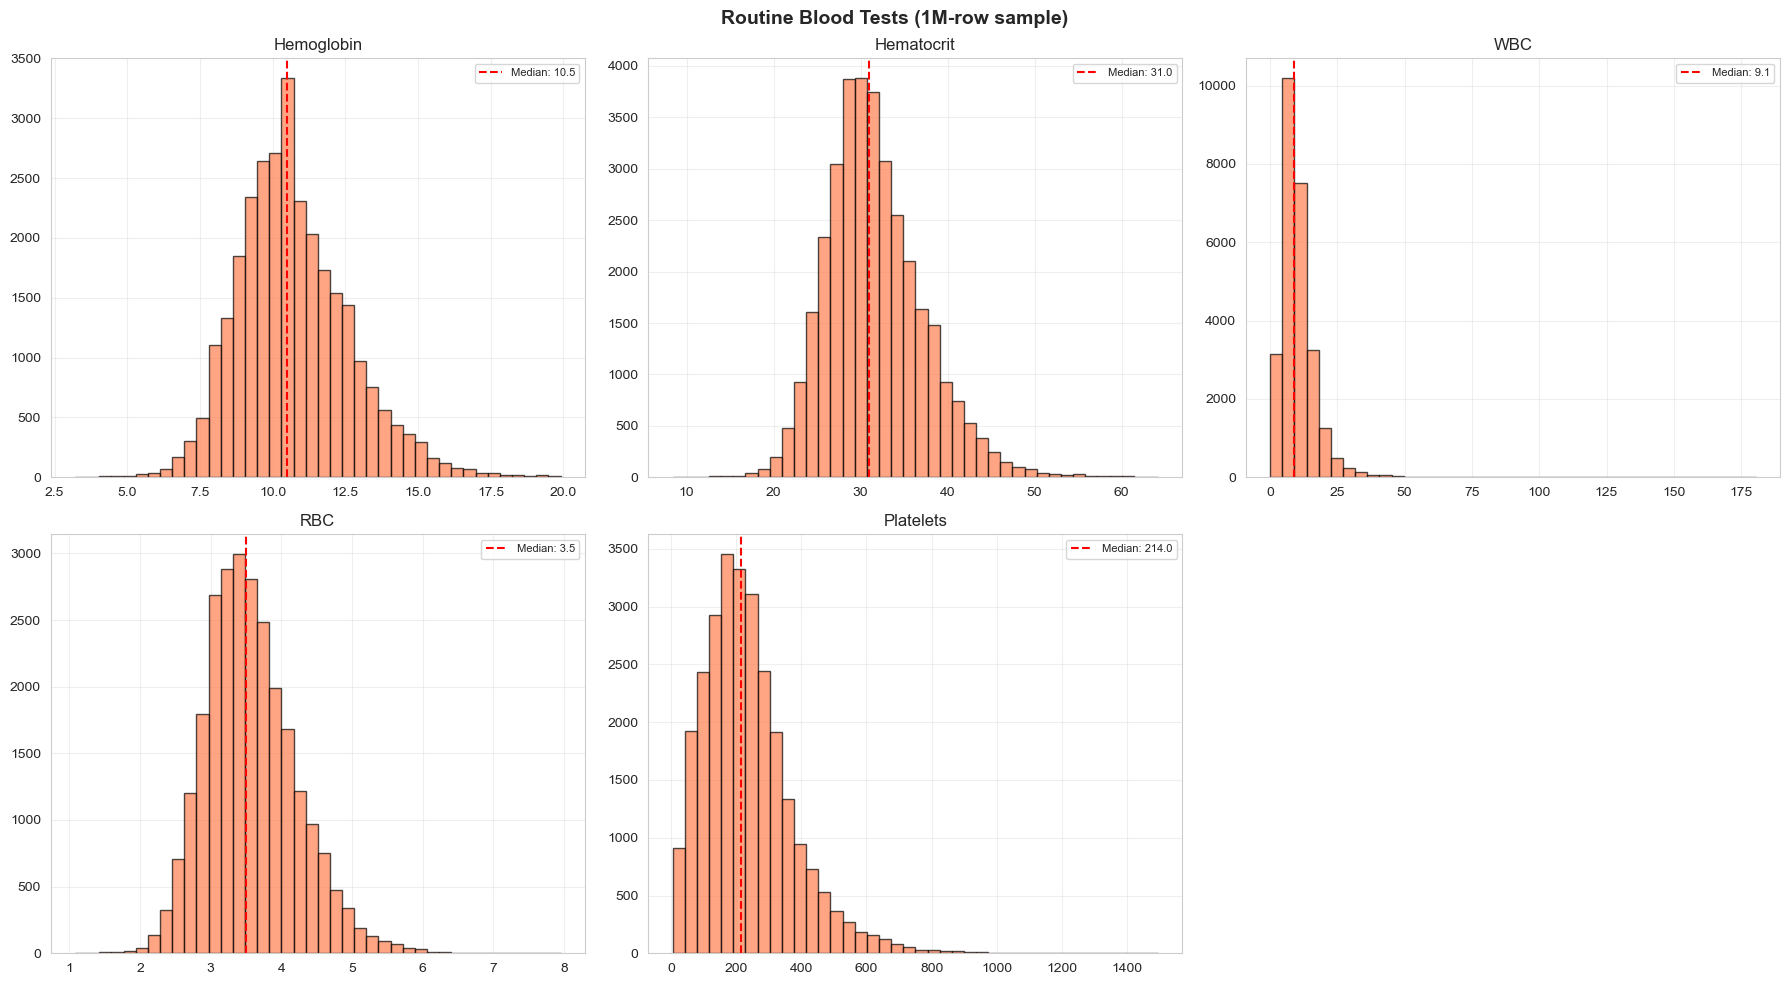

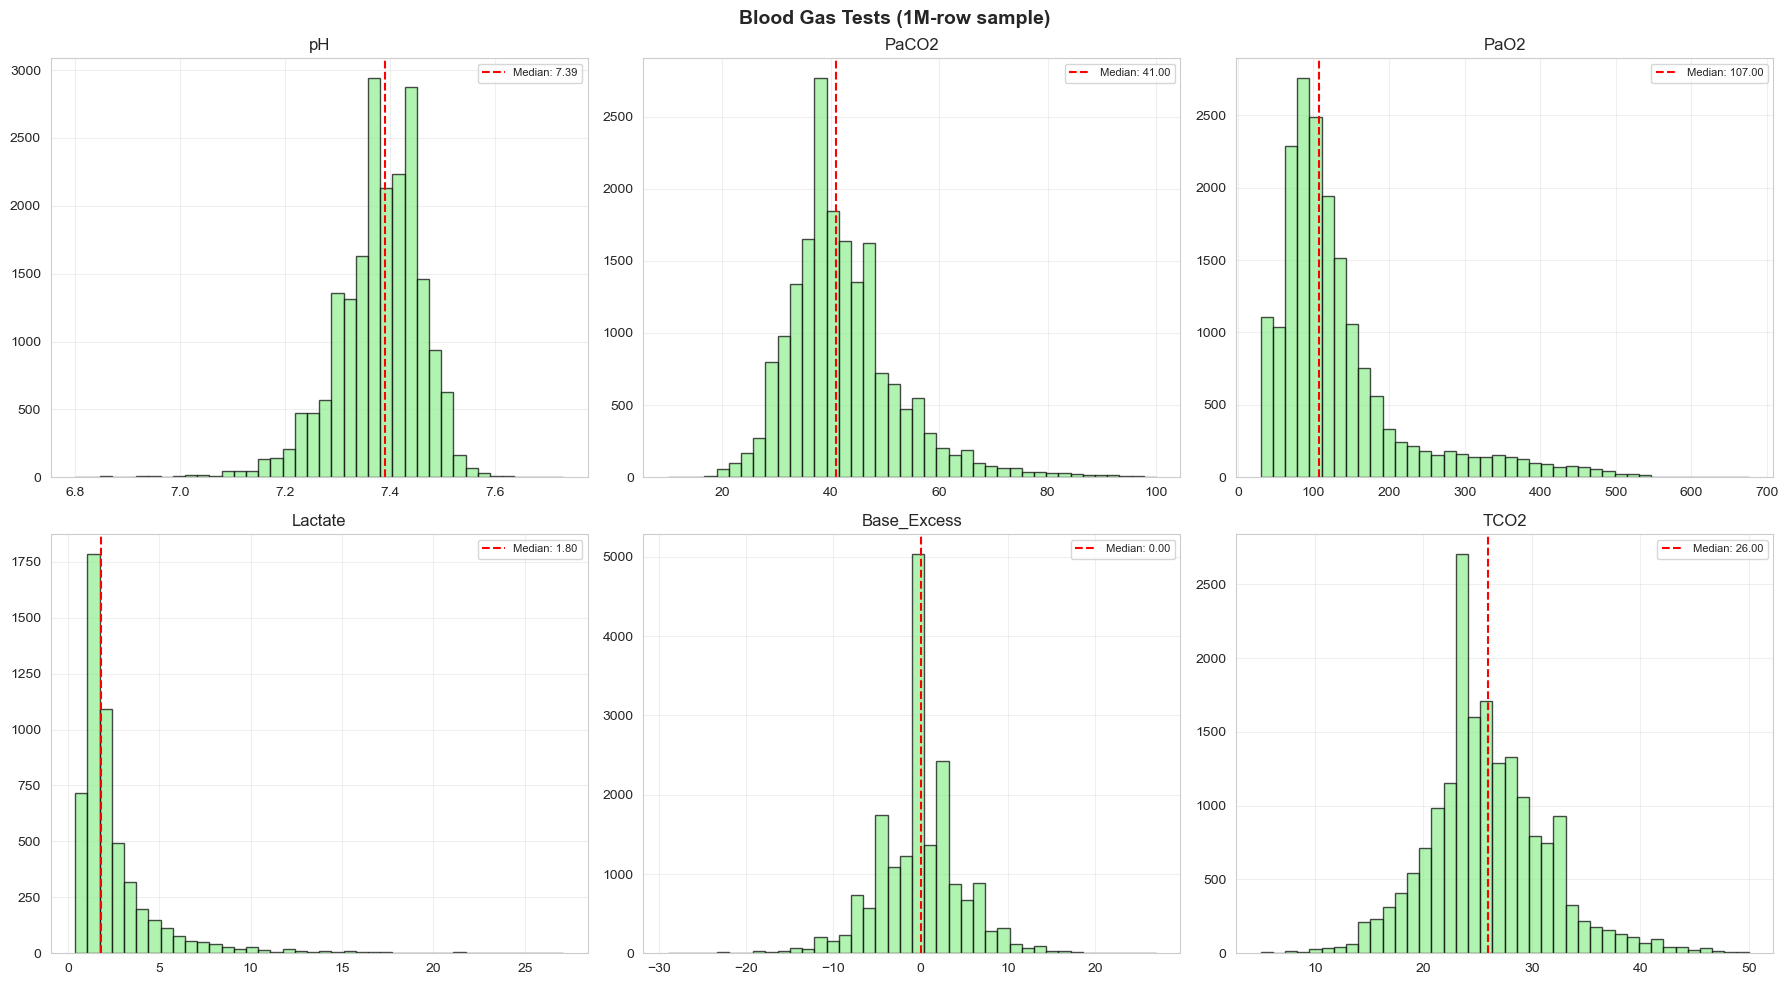

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Routine Blood Tests (1M-row sample)', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

routine = ['Hemoglobin', 'Hematocrit', 'WBC', 'RBC', 'Platelets']
for idx, test in enumerate(routine):
    ax   = axes_flat[idx]
    lo, hi = config.LAB_RANGES[test]
    data = labevents_sample[labevents_sample['ITEMID'].isin(config.ITEMIDS[test])]['VALUENUM'].dropna()
    data = data[(data >= lo) & (data <= hi)]
    ax.hist(data, bins=40, color='coral', alpha=0.7, edgecolor='black')
    ax.axvline(data.median(), color='red', ls='--', label=f'Median: {data.median():.1f}')
    ax.set_title(test)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes_flat[5].axis('off')
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / '05_labs_routine.png')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Blood Gas Tests (1M-row sample)', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

bg = ['pH', 'PaCO2', 'PaO2', 'Lactate', 'Base_Excess', 'TCO2']
for idx, test in enumerate(bg):
    ax   = axes_flat[idx]
    lo, hi = config.LAB_RANGES[test]
    data = labevents_sample[labevents_sample['ITEMID'].isin(config.ITEMIDS[test])]['VALUENUM'].dropna()
    data = data[(data >= lo) & (data <= hi)]
    if len(data):
        ax.hist(data, bins=40, color='lightgreen', alpha=0.7, edgecolor='black')
        ax.axvline(data.median(), color='red', ls='--', label=f'Median: {data.median():.2f}')
        ax.legend(fontsize=8)
    ax.set_title(test)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / '06_labs_bloodgas.png')
plt.show()
del labevents_sample


## INPUTEVENTS_MV + INPUTEVENTS_CV

Transfuzje krwi — kryterium A hemoragii.

In [17]:
# MetaVision (nowszy system, pełniejsze dane)
mv = pd.read_csv(config.MIMIC_DIR / 'INPUTEVENTS_MV.csv.gz', nrows=100_000)
mv_ids = config.ITEMIDS['Packed_RBC'] + config.ITEMIDS['FFP'] + \
         config.ITEMIDS['Platelet_Transfusion'] + config.ITEMIDS['Whole_Blood']

for product in ['Packed_RBC', 'FFP', 'Platelet_Transfusion', 'Whole_Blood']:
    m = mv[mv['ITEMID'].isin(config.ITEMIDS[product])]
    if len(m):
        print(f"  {product}: {len(m):,} records, {m['HADM_ID'].nunique():,} admissions")

del mv


  FFP: 202 records, 44 admissions
  Platelet_Transfusion: 138 records, 40 admissions


In [18]:
# CareVue (starszy system)
cv = pd.read_csv(config.MIMIC_DIR / 'INPUTEVENTS_CV.csv.gz', nrows=5_000_000)

for product in ['Packed_RBC', 'FFP', 'Platelet_Transfusion', 'Whole_Blood']:
    m = cv[cv['ITEMID'].isin(config.ITEMIDS[product])]
    if len(m):
        print(f"  {product}: {len(m):,} records, {m['HADM_ID'].dropna().nunique():,} admissions")

del cv


  Packed_RBC: 51,556 records, 9,910 admissions
  FFP: 22,792 records, 4,206 admissions
  Platelet_Transfusion: 8,141 records, 1,987 admissions


## D_ITEMS + D_LABITEMS — weryfikacja Item IDs

In [19]:
d_items    = pd.read_csv(config.MIMIC_DIR / 'D_ITEMS.csv.gz')
d_labitems = pd.read_csv(config.MIMIC_DIR / 'D_LABITEMS.csv.gz')

print(f"D_ITEMS shape:    {d_items.shape}")
print(f"D_LABITEMS shape: {d_labitems.shape}")

# Weryfikacja vital sign IDs
vs_ids = [i for v in ['HR','SBP','DBP','MBP','RESP','TEMP','SpO2']
            for i in config.ITEMIDS[v]]
found  = d_items[d_items['ITEMID'].isin(vs_ids)][['ITEMID','LABEL','DBSOURCE']]
print(f"\nVital ITEMIDs znalezione: {len(found)} / {len(vs_ids)}")
print(found.sort_values('ITEMID').to_string(index=False))


D_ITEMS shape:    (12487, 10)
D_LABITEMS shape: (753, 6)

Vital ITEMIDs znalezione: 30 / 30
 ITEMID                                 LABEL   DBSOURCE
     51                Arterial BP [Systolic]    carevue
     52                      Arterial BP Mean    carevue
    211                            Heart Rate    carevue
    442                  Manual BP [Systolic]    carevue
    443                  Manual BP Mean(calc)    carevue
    455                        NBP [Systolic]    carevue
    615                     Resp Rate (Total)    carevue
    618                      Respiratory Rate    carevue
    646                                  SpO2    carevue
    676                         Temperature C    carevue
    678                         Temperature F    carevue
   6701             Arterial BP #2 [Systolic]    carevue
   6702                   Arterial BP Mean #2    carevue
   8368               Arterial BP [Diastolic]    carevue
   8440                 Manual BP [Diastolic]    care

In [20]:
# Weryfikacja lab IDs
lab_ids = [i for t in ['Hemoglobin','Hematocrit','WBC','RBC','Platelets',
                        'pH','PaCO2','PaO2','Lactate','Base_Excess','TCO2']
             for i in config.ITEMIDS[t]]
found_labs = d_labitems[d_labitems['ITEMID'].isin(lab_ids)][['ITEMID','LABEL','FLUID','CATEGORY']]
print(f"Lab ITEMIDs znalezione: {len(found_labs)} / {len(lab_ids)}")
print(found_labs.sort_values('ITEMID').to_string(index=False))


Lab ITEMIDs znalezione: 14 / 14
 ITEMID                  LABEL FLUID   CATEGORY
  50802            Base Excess Blood  Blood Gas
  50804   Calculated Total CO2 Blood  Blood Gas
  50810 Hematocrit, Calculated Blood  Blood Gas
  50811             Hemoglobin Blood  Blood Gas
  50813                Lactate Blood  Blood Gas
  50818                   pCO2 Blood  Blood Gas
  50820                     pH Blood  Blood Gas
  50821                    pO2 Blood  Blood Gas
  51221             Hematocrit Blood Hematology
  51222             Hemoglobin Blood Hematology
  51265         Platelet Count Blood Hematology
  51279        Red Blood Cells Blood Hematology
  51300              WBC Count Blood Hematology
  51301      White Blood Cells Blood Hematology


## ICUSTAYS.csv

In [21]:
icustays = pd.read_csv(config.MIMIC_DIR / 'ICUSTAYS.csv.gz')
print(f"ICU stays:           {len(icustays):,}")
print(f"Unique patients:     {icustays['SUBJECT_ID'].nunique():,}")
print(f"Unique admissions:   {icustays['HADM_ID'].nunique():,}")

stays_per_adm = icustays.groupby('HADM_ID').size()
print(f"Stays per admission: mean={stays_per_adm.mean():.2f}, max={stays_per_adm.max()}")

icustays_eda = icustays.copy()
icustays_eda['INTIME']  = pd.to_datetime(icustays_eda['INTIME'])
icustays_eda['OUTTIME'] = pd.to_datetime(icustays_eda['OUTTIME'])
icustays_eda['ICU_LOS_DAYS'] = (icustays_eda['OUTTIME'] - icustays_eda['INTIME']).dt.total_seconds() / 86400

print(f"\nICU LOS (days): median={icustays_eda['ICU_LOS_DAYS'].median():.1f}, "      f"mean={icustays_eda['ICU_LOS_DAYS'].mean():.1f}, "      f"max={icustays_eda['ICU_LOS_DAYS'].max():.1f}")
print(f"Negative ICU LOS: {(icustays_eda['ICU_LOS_DAYS'] < 0).sum()}")
del icustays_eda


ICU stays:           61,532
Unique patients:     46,476
Unique admissions:   57,786
Stays per admission: mean=1.06, max=7

ICU LOS (days): median=2.1, mean=4.9, max=173.1
Negative ICU LOS: 0


## Cross-file validation

In [22]:
print("=" * 55)
print("CROSS-FILE VALIDATION")
print("=" * 55)

# 1. ADMISSIONS <-> PATIENTS
adm_subj = set(admissions['SUBJECT_ID'])
pat_subj = set(patients['SUBJECT_ID'])
print(f"\n1. ADMISSIONS <-> PATIENTS")
print(f"   Missing in PATIENTS: {len(adm_subj - pat_subj)}")
print(f"   Missing in ADMISSIONS: {len(pat_subj - adm_subj)}")

# 2. ADMISSIONS <-> ICUSTAYS
adm_hadm = set(admissions['HADM_ID'])
icu_hadm = set(icustays['HADM_ID'])
icu_coverage = len(icu_hadm) / len(adm_hadm) * 100
print(f"\n2. ADMISSIONS <-> ICUSTAYS")
print(f"   ICU coverage: {icu_coverage:.1f}% ({len(icu_hadm):,} / {len(adm_hadm):,} admissions)")
print(f"   ICU stays not in ADMISSIONS: {len(icu_hadm - adm_hadm)}")

# 3. Adult filter impact
patients_tmp = patients.copy()
admissions_tmp = admissions.copy()
patients_tmp['DOB'] = pd.to_datetime(patients_tmp['DOB'])
admissions_tmp['ADMITTIME'] = pd.to_datetime(admissions_tmp['ADMITTIME'])
age_data = admissions_tmp[['HADM_ID','SUBJECT_ID','ADMITTIME']].merge(
    patients_tmp[['SUBJECT_ID','DOB']], on='SUBJECT_ID')
age_data['AGE'] = (age_data['ADMITTIME'].dt.year - age_data['DOB'].dt.year).clip(upper=90)
adults = (age_data['AGE'] >= 18).sum()
print(f"\n3. Adult filter (≥18 years)")
print(f"   Adults:    {adults:,} ({adults/len(age_data)*100:.1f}%)")
print(f"   Pediatric: {len(age_data)-adults:,} ({(len(age_data)-adults)/len(age_data)*100:.1f}%) → filtrowane")

del patients_tmp, admissions_tmp, age_data
print("\n✅ Validation complete.")


CROSS-FILE VALIDATION

1. ADMISSIONS <-> PATIENTS
   Missing in PATIENTS: 0
   Missing in ADMISSIONS: 0

2. ADMISSIONS <-> ICUSTAYS
   ICU coverage: 98.0% (57,786 / 58,976 admissions)
   ICU stays not in ADMISSIONS: 0

3. Adult filter (≥18 years)
   Adults:    50,796 (86.1%)
   Pediatric: 8,180 (13.9%) → filtrowane

✅ Validation complete.


## Podsumowanie

| Plik | Rekordów | Rola w projekcie |
|---|---|---|
| ADMISSIONS | 58 976 | LOS, timestamps, linkage |
| PATIENTS | 46 520 | wiek, płeć |
| DIAGNOSES_ICD | 651 047 | identyfikacja traumy + wykluczenia |
| CHARTEVENTS | ~330M | sygnały życiowe (chunk extraction) |
| LABEVENTS | ~27M | morfologia + gazometria |
| INPUTEVENTS_CV/MV | — | transfuzje (kryterium A) |
| ICUSTAYS | 61 532 | timing ICU (opcjonalne) |
| D_ITEMS / D_LABITEMS | — | słowniki — weryfikacja item IDs |

**Wymagania preprocessingu (→ 02_preprocessing.ipynb):**
1. `ADMISSIONS`: filtr negatywny LOS (98 przypadków), konwersja timestamp
2. `PATIENTS`: wiek ≥ 18, obsługa anonimizacji >89 lat
3. `DIAGNOSES_ICD`: regex trauma pattern, wykluczenia wstrząsów
4. `CHARTEVENTS`: chunk extraction (1M/chunk), konwersja °F→°C, outlier removal
5. `LABEVENTS`: chunk extraction, outlier removal per LAB_RANGES
6. `INPUTEVENTS`: łączenie CV + MV, identyfikacja transfuzji


In [23]:
# ==============================================================================
# ŚLEDZTWO WSTRZĄSOWE I CHIRURGICZNE (Poszukiwanie zaginionych kohort)
# ==============================================================================
import pandas as pd
import numpy as np
import config

print("Załadowanie bazy pacjentów urazowych z cache...")
trauma_hadm = np.load(config.PROCESSED_DIR / 'trauma_hadm_ids.npy')
print(f"Baza pacjentów z urazem: {len(trauma_hadm)}")

# ==========================================
# 1. ŚLEDZTWO CHIRURGICZNE (Odrzucenia)
# ==========================================
print("\n" + "="*50)
print("--- ŚLEDZTWO 1: PROCEDURY CHIRURGICZNE ---")
procs = pd.read_csv(config.MIMIC_DIR / 'PROCEDURES_ICD.csv.gz')
trauma_procs = procs[procs['HADM_ID'].isin(trauma_hadm)].copy()

# Zakres 01-86 wg ICD-9-PCS to formalnie operacje
trauma_procs['IS_SURGERY'] = trauma_procs['ICD9_CODE'].astype(str).str.match(r'^(0[1-9]|[1-7][0-9]|8[0-6])', na=False)

surg_any = trauma_procs[trauma_procs['IS_SURGERY']]['HADM_ID'].nunique()
surg_seq_2 = trauma_procs[trauma_procs['IS_SURGERY'] & (trauma_procs['SEQ_NUM'] <= 2)]['HADM_ID'].nunique()
surg_seq_1 = trauma_procs[trauma_procs['IS_SURGERY'] & (trauma_procs['SEQ_NUM'] == 1)]['HADM_ID'].nunique()

print(f"Wykluczenia (operacja gdziekolwiek): {surg_any}")
print(f"Wykluczenia (operacja w TOP 2 głównych procedur): {surg_seq_2}")
print(f"Wykluczenia (operacja wyłącznie jako procedura GŁÓWNA): {surg_seq_1}")
print("-> CEL PUBLIKACJI (MIMIC-III): 2700 wykluczeń.")

print("\nTop 10 najczęstszych kodów 'operacyjnych' (01-86) u pacjentów z urazem:")
top_codes = trauma_procs[trauma_procs['IS_SURGERY']]['ICD9_CODE'].value_counts().head(10)
print(top_codes)
print("(Wskazówka: sprawdź kody w słowniku ICD-9. Możliwe, że autorzy nie wykluczali np. drobnych interwencji).")

# ==========================================
# 2. ŚLEDZTWO WSTRZĄSOWE (Asynchroniczność)
# ==========================================
print("\n" + "="*50)
print("--- ŚLEDZTWO 2: UKRYTE WSTRZĄSY W CHARTEVENTS ---")
print("Ładowanie próbek funkcji życiowych...")
cv = pd.read_csv(config.PROCESSED_DIR / 'chartevents_sample_vitals.csv')
cv['CHARTTIME'] = pd.to_datetime(cv['CHARTTIME']).dt.floor('30min')

# Filtr dla traumy
cv = cv[cv['HADM_ID'].isin(trauma_hadm)]

print("Pivotowanie danych...")
cv_wide = cv.pivot_table(index=['HADM_ID', 'CHARTTIME'], columns='VARIABLE', values='VALUENUM', aggfunc='median').reset_index()
cv_wide = cv_wide.sort_values(['HADM_ID', 'CHARTTIME'])

vs_cols = ['HR', 'SBP', 'DBP', 'MBP']
avail_cols = [c for c in vs_cols if c in cv_wide.columns]

print("\nTestowanie wpływu parametru ffill_limit (łączenie asynchronicznych pomiarów w czasie):")
# Sprawdzamy opcje od braku łączenia do przeciągania o max 6 godzin w przód
for ffill_limit in [0, 1, 2, 4, 8, 12]:
    temp = cv_wide.copy()
    # Forward-fill w obrębie tego samego HADM_ID
    temp[avail_cols] = temp.groupby('HADM_ID')[avail_cols].ffill(limit=ffill_limit)
    
    # Liczenie MAP
    if 'MBP' in temp.columns:
        temp['MAP'] = temp['MBP']
    else:
        temp['MAP'] = np.nan
    calc_mask = temp['MAP'].isna() & temp['SBP'].notna() & temp['DBP'].notna()
    temp.loc[calc_mask, 'MAP'] = temp.loc[calc_mask, 'DBP'] + (temp.loc[calc_mask, 'SBP'] - temp.loc[calc_mask, 'DBP']) / 3
    
    # Liczenie SI
    valid = temp['SBP'] > 0
    temp['SI'] = np.nan
    temp.loc[valid, 'SI'] = temp.loc[valid, 'HR'] / temp.loc[valid, 'SBP']
    
    # Identyfikacja szoku
    shock_mask = (temp['SI'] >= 1.0) & (temp['MAP'] <= 70)
    shock_count = temp[shock_mask]['HADM_ID'].nunique()
    
    czas_h = ffill_limit * 0.5
    print(f"Limit przeciągania {ffill_limit:>2} okien (max {czas_h:>4} h) -> Wykryto wstrząs u: {shock_count} pacjentów")

print("\n-> CEL PUBLIKACJI (MIMIC-III): 1028 pacjentów ze wstrząsem.")

Załadowanie bazy pacjentów urazowych z cache...
Baza pacjentów z urazem: 5176

--- ŚLEDZTWO 1: PROCEDURY CHIRURGICZNE ---
Wykluczenia (operacja gdziekolwiek): 3736
Wykluczenia (operacja w TOP 2 głównych procedur): 3530
Wykluczenia (operacja wyłącznie jako procedura GŁÓWNA): 3327
-> CEL PUBLIKACJI (MIMIC-III): 2700 wykluczeń.

Top 10 najczęstszych kodów 'operacyjnych' (01-86) u pacjentów z urazem:
ICD9_CODE
3893    1138
8659     593
3891     564
3404     448
311      407
3324     405
4311     371
387      316
7936     311
7935     300
Name: count, dtype: int64
(Wskazówka: sprawdź kody w słowniku ICD-9. Możliwe, że autorzy nie wykluczali np. drobnych interwencji).

--- ŚLEDZTWO 2: UKRYTE WSTRZĄSY W CHARTEVENTS ---
Ładowanie próbek funkcji życiowych...
Pivotowanie danych...

Testowanie wpływu parametru ffill_limit (łączenie asynchronicznych pomiarów w czasie):
Limit przeciągania  0 okien (max  0.0 h) -> Wykryto wstrząs u: 1809 pacjentów
Limit przeciągania  1 okien (max  0.5 h) -> Wykryto 

In [24]:
# ==============================================================================
# ŚLEDZTWO 3: TRANSFUZJE KRWI (Kryterium A)
# ==============================================================================
import pandas as pd
import numpy as np
import config

print("--- ŚLEDZTWO 3: UKRYTE RESTRYKCJE W TRANSFUZJACH ---")

# Ładujemy dane o transfuzjach z cache
transfusions = pd.read_csv(config.PROCESSED_DIR / 'inputevents_sample_transfusions.csv')

# Ładujemy admisje z cache (żeby mieć ADMITTIME) i łączymy
admissions_sample = pd.read_csv(config.MIMIC_DIR / 'ADMISSIONS.csv.gz')
trans_merged = transfusions.merge(admissions_sample[['HADM_ID', 'ADMITTIME']], on='HADM_ID', how='left')

# Obliczamy czas od przyjęcia (uwzględniając ujemny czas z SOR)
trans_merged['TRANSFUSION_TIME'] = pd.to_datetime(trans_merged['TRANSFUSION_TIME'])
trans_merged['ADMITTIME'] = pd.to_datetime(trans_merged['ADMITTIME'])
trans_merged['HOURS_FROM_ADMIT'] = (trans_merged['TRANSFUSION_TIME'] - trans_merged['ADMITTIME']).dt.total_seconds() / 3600

# Ładujemy listę pacjentów ze wstrząsem z naszego aktualnego pipeline'u
shock_onsets = pd.read_csv(config.PROCESSED_DIR / 'shock_onsets.csv')
shock_hadm = set(shock_onsets['HADM_ID'].unique())

# Filtrujemy transfuzje tylko dla pacjentów, którzy mieli wstrząs
shock_trans = trans_merged[trans_merged['HADM_ID'].isin(shock_hadm)].copy()

print(f"Pacjenci we wstrząsie z JAKĄKOLWIEK transfuzją KIEDYKOLWIEK: {shock_trans['HADM_ID'].nunique()} (Nasz obecny wynik)")
print("-> CEL PUBLIKACJI (MIMIC-III): ~69 pacjentów.\n")

# Definiujemy produkty
all_products = shock_trans['PRODUCT'].unique()
red_blood_only = ['Packed_RBC', 'Whole_Blood']

print("Testowanie restrykcji czasowych i produktowych:")
print("-" * 60)
print(f"{'Limit czasowy':<20} | {'Wszystkie produkty':<20} | {'Tylko krwinki (PRBC/WB)'}")
print("-" * 60)

for hrs in [6, 12, 24, 48, 72, 9999]:
    # Włączamy okno od -24h (SOR) do X godzin po przyjęciu
    time_mask = shock_trans['HOURS_FROM_ADMIT'].between(-24, hrs)
    
    # Wszystkie produkty (FFP, Płytki, Krew)
    count_all = shock_trans[time_mask]['HADM_ID'].nunique()
    
    # Tylko czerwone krwinki / krew pełna
    prbc_mask = shock_trans['PRODUCT'].isin(red_blood_only)
    count_red = shock_trans[time_mask & prbc_mask]['HADM_ID'].nunique()
    
    label = f"W ciągu {hrs}h" if hrs != 9999 else "Cały pobyt (Bez limitu)"
    print(f"{label:<20} | {count_all:<20} | {count_red}")

print("-" * 60)

--- ŚLEDZTWO 3: UKRYTE RESTRYKCJE W TRANSFUZJACH ---
Pacjenci we wstrząsie z JAKĄKOLWIEK transfuzją KIEDYKOLWIEK: 243 (Nasz obecny wynik)
-> CEL PUBLIKACJI (MIMIC-III): ~69 pacjentów.

Testowanie restrykcji czasowych i produktowych:
------------------------------------------------------------
Limit czasowy        | Wszystkie produkty   | Tylko krwinki (PRBC/WB)
------------------------------------------------------------
W ciągu 6h           | 119                  | 61
W ciągu 12h          | 149                  | 82
W ciągu 24h          | 169                  | 96
W ciągu 48h          | 190                  | 114
W ciągu 72h          | 206                  | 128
Cały pobyt (Bez limitu) | 243                  | 171
------------------------------------------------------------


In [25]:
import sys
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

admissions_sample = pd.read_csv(config.PROCESSED_DIR / 'vitals_with_shock.csv', 
                                  parse_dates=['CHARTTIME'], nrows=1)
# Wczytaj dane
vitals_w = pd.read_csv(config.PROCESSED_DIR / 'vitals_with_shock.csv', parse_dates=['CHARTTIME'])
shock_onsets = pd.read_csv(config.PROCESSED_DIR / 'shock_onsets.csv')
# Po (obsługa .gz):
_adm_path = config.MIMIC_DIR / 'ADMISSIONS.csv'
if not _adm_path.exists():
    _adm_path = config.MIMIC_DIR / 'ADMISSIONS.csv.gz'
admissions_full = pd.read_csv(_adm_path)
admissions_full['ADMITTIME'] = pd.to_datetime(admissions_full['ADMITTIME'])
sample_ids = np.load(config.PROCESSED_DIR / 'sample_subject_ids.npy', allow_pickle=True)
trauma_hadm_sample = np.load(config.PROCESSED_DIR / 'trauma_hadm_ids.npy', allow_pickle=True)

admissions_sample = admissions_full[admissions_full['SUBJECT_ID'].isin(sample_ids)].copy()
trauma_vitals = vitals_w[vitals_w['HADM_ID'].isin(trauma_hadm_sample)].copy()

print(f"Vitals trauma rows: {len(trauma_vitals):,}")
print(f"Znany wynik (z agregacją 30min): 649 admisji z szokiem")
print(f"Cel publikacji: 1,028")

Vitals trauma rows: 219,696
Znany wynik (z agregacją 30min): 649 admisji z szokiem
Cel publikacji: 1,028


Wiersze z SHOCK=True: 6,813
Unikalne admisje z szokiem: 716

Rozkład admisji z szokiem wg okna czasowego:
TIME_BIN
[-24,0)      21
[0,6)       257
[6,12)      215
[12,24)     230
[24,48)     207
[48,72)     118
[72,168)    163
>168h       169

Szok BEZ filtra czasowego: 716 admisji
Szok Z filtrem >= -24h:    649 admisji


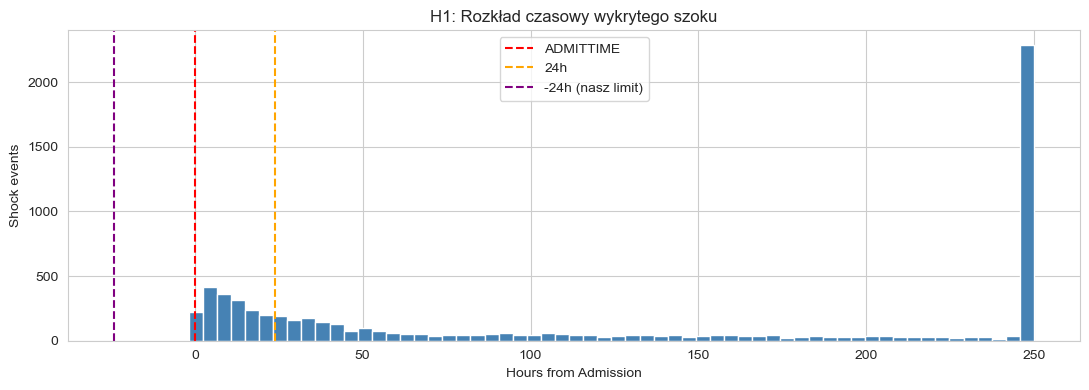

In [26]:
shock_rows = trauma_vitals[trauma_vitals['SHOCK'] == True].copy()
print(f"Wiersze z SHOCK=True: {len(shock_rows):,}")
print(f"Unikalne admisje z szokiem: {shock_rows['HADM_ID'].nunique():,}")

bins   = [-999, -24, 0, 6, 12, 24, 48, 72, 168, 9999]
labels = ['<-24h', '[-24,0)', '[0,6)', '[6,12)', '[12,24)', '[24,48)', '[48,72)', '[72,168)', '>168h']
shock_rows['TIME_BIN'] = pd.cut(shock_rows['HOURS_FROM_ADMIT'], bins=bins, labels=labels)

dist = shock_rows.groupby('TIME_BIN', observed=True)['HADM_ID'].nunique().rename('admisje_z_szokiem')
print("\nRozkład admisji z szokiem wg okna czasowego:")
print(dist.to_string())

# Ile admisji MA szok ale WYŁĄCZNIE poza oknem >= -24?
all_shock_hadm = trauma_vitals[
    (trauma_vitals['SI'] >= 1.0) & (trauma_vitals['MAP'] <= 70)
]['HADM_ID'].unique()
print(f"\nSzok BEZ filtra czasowego: {len(all_shock_hadm):,} admisji")
print(f"Szok Z filtrem >= -24h:    649 admisji")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(shock_rows['HOURS_FROM_ADMIT'].clip(-30, 250), bins=60, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', ls='--', lw=1.5, label='ADMITTIME')
ax.axvline(24, color='orange', ls='--', lw=1.5, label='24h')
ax.axvline(-24, color='purple', ls='--', lw=1.5, label='-24h (nasz limit)')
ax.set_xlabel('Hours from Admission'); ax.set_ylabel('Shock events')
ax.set_title('H1: Rozkład czasowy wykrytego szoku')
ax.legend(); plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'eda_shock_H1_time.png', dpi=100)
plt.show()

In [27]:
# Wczytaj surowe chartevents
chartevents = pd.read_csv(config.PROCESSED_DIR / 'chartevents_sample_vitals.csv', parse_dates=['CHARTTIME'])
chartevents_trauma = chartevents[chartevents['HADM_ID'].isin(trauma_hadm_sample)].copy()

print(f"Surowe wpisy chartevents (trauma): {len(chartevents_trauma):,}")

# Pivot BEZ agregacji 30-min — użyj 'last' per dokładny czas
vitals_raw = chartevents_trauma.pivot_table(
    index=['HADM_ID', 'CHARTTIME'],
    columns='VARIABLE', values='VALUENUM', aggfunc='last'
).reset_index()
vitals_raw.columns.name = None

# SI i MAP na surowych pomiarach
if 'HR' in vitals_raw.columns and 'SBP' in vitals_raw.columns:
    valid = vitals_raw['SBP'] > 0
    vitals_raw['SI'] = np.nan
    vitals_raw.loc[valid, 'SI'] = vitals_raw.loc[valid, 'HR'] / vitals_raw.loc[valid, 'SBP']
    vitals_raw.loc[vitals_raw['SI'] > 4, 'SI'] = np.nan

vitals_raw['MAP'] = np.nan
if 'MBP' in vitals_raw.columns:
    vitals_raw['MAP'] = vitals_raw['MBP']
if 'SBP' in vitals_raw.columns and 'DBP' in vitals_raw.columns:
    calc = vitals_raw['MAP'].isna() & vitals_raw['SBP'].notna() & vitals_raw['DBP'].notna()
    vitals_raw.loc[calc, 'MAP'] = (
        vitals_raw.loc[calc, 'DBP'] + (vitals_raw.loc[calc, 'SBP'] - vitals_raw.loc[calc, 'DBP']) / 3
    )

vitals_raw = vitals_raw.merge(
    admissions_sample[['HADM_ID', 'ADMITTIME', 'DEATHTIME']], on='HADM_ID', how='left'
)
vitals_raw['ADMITTIME'] = pd.to_datetime(vitals_raw['ADMITTIME'])
vitals_raw['HOURS'] = (vitals_raw['CHARTTIME'] - vitals_raw['ADMITTIME']).dt.total_seconds() / 3600

shock_raw_mask = (vitals_raw['SI'] >= 1.0) & (vitals_raw['MAP'] <= 70) & (vitals_raw['HOURS'] >= -24)
shock_raw_hadm = vitals_raw[shock_raw_mask]['HADM_ID'].nunique()

print(f"\nSzok z agregacją 30-min (obecny):  649 admisji")
print(f"Szok bez agregacji (surowe):        {shock_raw_hadm:,} admisji")
print(f"Różnica:                            {shock_raw_hadm - 649:+,}")
print(f"Cel publikacji:                     1,028")
print(f"Pokrycie celu bez agregacji:        {shock_raw_hadm/1028*100:.1f}%")

# Admisje które zyskaliśmy (mają szok bez agregacji, nie mają z agregacją)
gained = set(vitals_raw[shock_raw_mask]['HADM_ID'].unique()) - set(shock_rows['HADM_ID'].unique())
print(f"\nNowe admisje wykryte bez agregacji: {len(gained):,}")

Surowe wpisy chartevents (trauma): 3,781,157

Szok z agregacją 30-min (obecny):  649 admisji
Szok bez agregacji (surowe):        1,897 admisji
Różnica:                            +1,248
Cel publikacji:                     1,028
Pokrycie celu bez agregacji:        184.5%

Nowe admisje wykryte bez agregacji: 1,209


Pokrycie SI i MAP w vitals (trauma admisje):
  Wiersze z SI (nie-NaN):        218,062 (99.3%)
  Wiersze z MAP (nie-NaN):       218,907 (99.6%)
  Wiersze z oboma:               218,052 (99.3%)

  SI >= 1.0:                     11,891
  MAP <= 70:                     47,803
  SI>=1 AND MAP<=70 (szok):      6,813

  SI>=1 ale MAP=NaN (stracone):  6
  MAP<=70 ale SI=NaN (stracone): 160

Admisje z SI>=1 ale BRAK MAP:    2
→ To górna granica szoku utraconego przez brakujące MAP


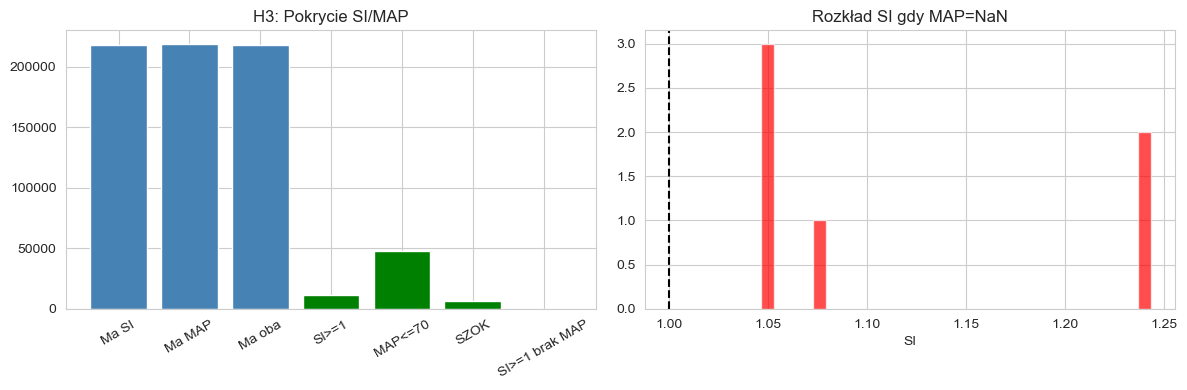

In [28]:
has_si  = trauma_vitals['SI'].notna()
has_map = trauma_vitals['MAP'].notna()
si_ok   = trauma_vitals['SI'] >= 1.0
map_ok  = trauma_vitals['MAP'] <= 70

print("Pokrycie SI i MAP w vitals (trauma admisje):")
print(f"  Wiersze z SI (nie-NaN):        {has_si.sum():,} ({has_si.mean()*100:.1f}%)")
print(f"  Wiersze z MAP (nie-NaN):       {has_map.sum():,} ({has_map.mean()*100:.1f}%)")
print(f"  Wiersze z oboma:               {(has_si & has_map).sum():,} ({(has_si & has_map).mean()*100:.1f}%)")
print()
print(f"  SI >= 1.0:                     {si_ok.sum():,}")
print(f"  MAP <= 70:                     {map_ok.sum():,}")
print(f"  SI>=1 AND MAP<=70 (szok):      {(si_ok & map_ok).sum():,}")
print()
print(f"  SI>=1 ale MAP=NaN (stracone):  {(si_ok & ~has_map).sum():,}")
print(f"  MAP<=70 ale SI=NaN (stracone): {(map_ok & ~has_si).sum():,}")

lost_hadm = trauma_vitals[si_ok & ~has_map]['HADM_ID'].nunique()
print(f"\nAdmisje z SI>=1 ale BRAK MAP:    {lost_hadm:,}")
print("→ To górna granica szoku utraconego przez brakujące MAP")

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = {
    'Ma SI': has_si.sum(), 'Ma MAP': has_map.sum(), 'Ma oba': (has_si & has_map).sum(),
    'SI>=1': si_ok.sum(), 'MAP<=70': map_ok.sum(), 'SZOK': (si_ok & map_ok).sum(),
    'SI>=1 brak MAP': (si_ok & ~has_map).sum()
}
axes[0].bar(list(data.keys()), list(data.values()), color=['steelblue']*3 + ['green']*3 + ['red'])
axes[0].set_title('H3: Pokrycie SI/MAP'); axes[0].tick_params(axis='x', rotation=30)

# Rozkład SI przy brakującym MAP
si_no_map = trauma_vitals[si_ok & ~has_map]['SI'].dropna()
axes[1].hist(si_no_map, bins=30, color='red', alpha=0.7)
axes[1].axvline(1.0, color='black', ls='--')
axes[1].set_title('Rozkład SI gdy MAP=NaN'); axes[1].set_xlabel('SI')
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'eda_shock_H3_map_coverage.png', dpi=100)
plt.show()

In [29]:
# Wariant: MAP tylko z pomiaru MBP (nie kalkulowany z SBP/DBP)
si_ok_tw = trauma_vitals['SI'] >= 1.0

# MAP tylko zmierzony
mbp_measured = trauma_vitals['MBP'].notna() if 'MBP' in trauma_vitals.columns else pd.Series(False, index=trauma_vitals.index)
map_measured_ok = mbp_measured & (trauma_vitals['MBP'] <= 70) if 'MBP' in trauma_vitals.columns else pd.Series(False, index=trauma_vitals.index)

# MAP kalkulowany
calc_map_ok = trauma_vitals['MAP'] <= 70

shock_measured_map = trauma_vitals[si_ok_tw & map_measured_ok]['HADM_ID'].nunique()
shock_any_map = trauma_vitals[si_ok_tw & calc_map_ok]['HADM_ID'].nunique()

print(f"Szok z MAP tylko zmierzonym (MBP): {shock_measured_map:,} admisji")
print(f"Szok z MAP (zmierzony + kalkulowany): {shock_any_map:,} admisji  ← obecny")
print(f"Dodatkowe szoki z MAP kalkulowanego: {shock_any_map - shock_measured_map:+,}")
print()

# Sprawdź ile MAP pochodzi z kalkulacji vs pomiaru
if 'MBP' in trauma_vitals.columns:
    has_mbp = trauma_vitals['MBP'].notna()
    has_calc_map = trauma_vitals['MAP'].notna() & ~has_mbp
    print(f"Wiersze z MAP zmierzonym (MBP): {has_mbp.sum():,} ({has_mbp.mean()*100:.1f}%)")
    print(f"Wiersze z MAP kalkulowanym:     {has_calc_map.sum():,} ({has_calc_map.mean()*100:.1f}%)")

Szok z MAP tylko zmierzonym (MBP): 520 admisji
Szok z MAP (zmierzony + kalkulowany): 716 admisji  ← obecny
Dodatkowe szoki z MAP kalkulowanego: +196

Wiersze z MAP zmierzonym (MBP): 164,857 (75.0%)
Wiersze z MAP kalkulowanym:     54,050 (24.6%)


In [30]:
print("=" * 60)
print("WYNIKI ŚLEDZTWA — ROZBIEŻNOŚĆ SHOCK")
print("=" * 60)
print()
print(f"Baseline (obecny, z agregacją 30-min): 649")
print(f"Cel publikacji:                       1,028")
print(f"Gap do wyjaśnienia:                    +379")
print()
print("Wyniki hipotez:")
print("  H1 (okno czasowe)     → patrz histogram powyżej")
print("  H2 (brak agregacji)   → kluczowy wynik komórki H2")
print("  H3 (brakujące MAP)    → patrz liczba 'straconych' admisji")
print("  H4 (źródło MAP)       → patrz różnica measured vs calculated")

WYNIKI ŚLEDZTWA — ROZBIEŻNOŚĆ SHOCK

Baseline (obecny, z agregacją 30-min): 649
Cel publikacji:                       1,028
Gap do wyjaśnienia:                    +379

Wyniki hipotez:
  H1 (okno czasowe)     → patrz histogram powyżej
  H2 (brak agregacji)   → kluczowy wynik komórki H2
  H3 (brakujące MAP)    → patrz liczba 'straconych' admisji
  H4 (źródło MAP)       → patrz różnica measured vs calculated


In [31]:
# ═══════════════════════════════════════════════════════
# H2b: Testowanie różnych strategii agregacji
# ═══════════════════════════════════════════════════════
results = {}

# Opcja A: 30-min MIN (najgorszy pomiar w oknie)
for aggfunc in ['min', 'median', 'max']:
    vw = chartevents_trauma.copy()
    vw['CHARTTIME_R'] = vw['CHARTTIME'].dt.floor('30min')
    piv = vw.pivot_table(
        index=['HADM_ID','CHARTTIME_R'], columns='VARIABLE',
        values='VALUENUM', aggfunc=aggfunc
    ).reset_index()
    piv.columns.name = None
    if 'HR' in piv.columns and 'SBP' in piv.columns:
        piv['SI'] = np.where(piv['SBP']>0, piv['HR']/piv['SBP'], np.nan)
        piv.loc[piv['SI']>4, 'SI'] = np.nan
    piv['MAP'] = piv.get('MBP', np.nan)
    if 'SBP' in piv.columns and 'DBP' in piv.columns:
        calc = piv['MAP'].isna()
        piv.loc[calc,'MAP'] = piv.loc[calc,'DBP'] + (piv.loc[calc,'SBP']-piv.loc[calc,'DBP'])/3
    piv = piv.merge(admissions_sample[['HADM_ID','ADMITTIME']], on='HADM_ID', how='left')
    piv['ADMITTIME'] = pd.to_datetime(piv['ADMITTIME'])
    piv['H'] = (piv['CHARTTIME_R'] - piv['ADMITTIME']).dt.total_seconds()/3600
    n = piv[(piv['SI']>=1.0) & (piv['MAP']<=70) & (piv['H']>=-24)]['HADM_ID'].nunique()
    results[f'30min_{aggfunc}'] = n

# Opcja B: Raw + wymaganie ≥2 kolejnych pomiarów spełniających kryteria
shock_cand = vitals_raw[(vitals_raw['SI']>=1.0) & (vitals_raw['MAP']<=70) & (vitals_raw['HOURS']>=-24)].copy()
shock_cand = shock_cand.sort_values(['HADM_ID','CHARTTIME'])
shock_cand['prev_hadm'] = shock_cand['HADM_ID'].shift(1)
shock_cand['consecutive'] = shock_cand['HADM_ID'] == shock_cand['prev_hadm']
consec_shock = shock_cand[shock_cand['consecutive']]['HADM_ID'].nunique()
results['raw_2consec'] = consec_shock

# Opcja C: 5-min i 10-min okna z median
for mins in [5, 10, 15]:
    vw = chartevents_trauma.copy()
    vw['CHARTTIME_R'] = vw['CHARTTIME'].dt.floor(f'{mins}min')
    piv = vw.pivot_table(
        index=['HADM_ID','CHARTTIME_R'], columns='VARIABLE',
        values='VALUENUM', aggfunc='median'
    ).reset_index()
    piv.columns.name = None
    if 'HR' in piv.columns and 'SBP' in piv.columns:
        piv['SI'] = np.where(piv['SBP']>0, piv['HR']/piv['SBP'], np.nan)
        piv.loc[piv['SI']>4, 'SI'] = np.nan
    piv['MAP'] = piv.get('MBP', np.nan)
    if 'SBP' in piv.columns and 'DBP' in piv.columns:
        calc = piv['MAP'].isna()
        piv.loc[calc,'MAP'] = piv.loc[calc,'DBP'] + (piv.loc[calc,'SBP']-piv.loc[calc,'DBP'])/3
    piv = piv.merge(admissions_sample[['HADM_ID','ADMITTIME']], on='HADM_ID', how='left')
    piv['ADMITTIME'] = pd.to_datetime(piv['ADMITTIME'])
    piv['H'] = (piv['CHARTTIME_R'] - piv['ADMITTIME']).dt.total_seconds()/3600
    n = piv[(piv['SI']>=1.0) & (piv['MAP']<=70) & (piv['H']>=-24)]['HADM_ID'].nunique()
    results[f'{mins}min_median'] = n

print("Wyniki porównania strategii agregacji:")
print(f"  {'Metoda':<20} {'Admisje':>8}  {'%celu':>7}")
print("  " + "-"*38)
for k, v in sorted(results.items(), key=lambda x: x[1]):
    pct = v/1028*100
    flag = "✅" if abs(pct-100)<15 else ("🟡" if abs(pct-100)<30 else "🔴")
    print(f"  {flag} {k:<20} {v:>8,}  {pct:>6.1f}%")
print(f"\n  Cel publikacji:      {'1,028':>8}  {'100.0':>7}%")
print(f"  Nasz obecny(30m-med):{'649':>8}  {' 63.1':>7}%")
print(f"  Raw bez agregacji:   {'1,774':>8}  {'172.6':>7}%")

Wyniki porównania strategii agregacji:
  Metoda                Admisje    %celu
  --------------------------------------
  🔴 raw_2consec             1,457   141.7%
  🔴 30min_max               1,734   168.7%
  🔴 30min_median            1,809   176.0%
  🔴 15min_median            1,877   182.6%
  🔴 10min_median            1,902   185.0%
  🔴 5min_median             1,924   187.2%
  🔴 30min_min               1,966   191.2%

  Cel publikacji:         1,028    100.0%
  Nasz obecny(30m-med):     649     63.1%
  Raw bez agregacji:      1,774    172.6%


In [32]:
trauma_v = vitals_w[vitals_w['HADM_ID'].isin(trauma_hadm_sample)].copy()
trauma_v['ADMITTIME'] = pd.to_datetime(
    admissions_sample.set_index('HADM_ID').loc[trauma_v['HADM_ID'].values, 'ADMITTIME'].values
)

for thresh in [0.7, 0.8, 0.9, 1.0, 1.1]:
    n = trauma_v[trauma_v['SI'] >= thresh]['HADM_ID'].nunique()
    print(f"SI >= {thresh} alone:         {n:,}")

n_full = trauma_v[
    (trauma_v['SI'] >= 1.0) & (trauma_v['MAP'] <= 70)
]['HADM_ID'].nunique()
n_map65 = trauma_v[
    (trauma_v['SI'] >= 1.0) & (trauma_v['MAP'] <= 65)
]['HADM_ID'].nunique()
print(f"SI>=1 AND MAP<=70 (nasz):    {n_full:,}")
print(f"SI>=1 AND MAP<=65:           {n_map65:,}")
print(f"Cel: 1,028")

SI >= 0.7 alone:         2,089
SI >= 0.8 alone:         1,697
SI >= 0.9 alone:         1,240
SI >= 1.0 alone:         890
SI >= 1.1 alone:         598
SI>=1 AND MAP<=70 (nasz):    716
SI>=1 AND MAP<=65:           616
Cel: 1,028


In [33]:
trauma_v = vitals_w[vitals_w['HADM_ID'].isin(trauma_hadm_sample)].copy()

combos = {
    'SI>=0.9 AND MAP<=70':           ((trauma_v['SI']>=0.9) & (trauma_v['MAP']<=70)),
    'SI>=0.9 AND MAP<=75':           ((trauma_v['SI']>=0.9) & (trauma_v['MAP']<=75)),
    'SI>=0.9 AND MAP<=80':           ((trauma_v['SI']>=0.9) & (trauma_v['MAP']<=80)),
    'SI>=1.0 OR  MAP<=70':           ((trauma_v['SI']>=1.0) | (trauma_v['MAP']<=70)),
    'SI>=0.9 alone':                 (trauma_v['SI']>=0.9),
    'SI>=0.9 (H<=-6 to 48h)':       ((trauma_v['SI']>=0.9) & (trauma_v['HOURS_FROM_ADMIT']>=-6) & (trauma_v['HOURS_FROM_ADMIT']<=48)),
    'SI>=1.0 (H<=-6 to 48h)':       ((trauma_v['SI']>=1.0) & (trauma_v['HOURS_FROM_ADMIT']>=-6) & (trauma_v['HOURS_FROM_ADMIT']<=48)),
    'SI>=0.9 AND MAP<=70 (<=48h)':   ((trauma_v['SI']>=0.9) & (trauma_v['MAP']<=70) & (trauma_v['HOURS_FROM_ADMIT']<=48)),
}

print(f"{'Kombinacja':<35} {'Admisje':>8}  {'%celu':>7}")
print("-" * 55)
for label, mask in combos.items():
    n = trauma_v[mask]['HADM_ID'].nunique()
    pct = n/1028*100
    flag = '✅' if abs(pct-100)<8 else ('🟡' if abs(pct-100)<20 else '🔴')
    print(f"{flag} {label:<33} {n:>8,}  {pct:>6.1f}%")
print(f"{'Cel publikacji':<35} {'1,028':>8}  {'100.0':>7}%")
print(f"{'Nasz (SI>=1 AND MAP<=70)':<35} {'649':>8}  {' 63.1':>7}%")

Kombinacja                           Admisje    %celu
-------------------------------------------------------
✅ SI>=0.9 AND MAP<=70                    995    96.8%
✅ SI>=0.9 AND MAP<=75                  1,093   106.3%
🟡 SI>=0.9 AND MAP<=80                  1,151   112.0%
🔴 SI>=1.0 OR  MAP<=70                  2,030   197.5%
🔴 SI>=0.9 alone                        1,240   120.6%
✅ SI>=0.9 (H<=-6 to 48h)               1,078   104.9%
🔴 SI>=1.0 (H<=-6 to 48h)                 706    68.7%
🔴 SI>=0.9 AND MAP<=70 (<=48h)            819    79.7%
Cel publikacji                         1,028    100.0%
Nasz (SI>=1 AND MAP<=70)                 649     63.1%


In [34]:
import pandas as pd
import numpy as np
import config

print("="*60)
print("🔍 ŚLEDZTWO 4: WIELKI AUDYT ZAŁOŻEŃ DOMYŚLNYCH")
print("="*60)

# Wczytanie tabel pomocniczych
adm = pd.read_csv(config.MIMIC_DIR / 'ADMISSIONS.csv.gz')
cases = pd.read_csv(config.PROCESSED_DIR / 'hemorrhage_classification.csv')

# Automatyczne dopasowanie nazwy kolumny (LABEL, THS, THS_GROUP itp.)
target_col = None
for col in ['THS_GROUP', 'LABEL', 'THS', 'IS_THS']:
    if col in cases.columns:
        target_col = col
        break
        
if target_col is None:
    # Bezpieczny Fallback - bierzemy grupy prosto z plików do modelowania
    feat = pd.read_csv(config.WINDOWS_DIR / 'features_T1h_VS.csv')
    ths_hadm = feat[feat['LABEL'] == 1]['HADM_ID'].unique()
    non_ths_hadm = feat[feat['LABEL'] == 0]['HADM_ID'].unique()
else:
    ths_hadm = cases[cases[target_col] == 1]['HADM_ID'].unique()
    non_ths_hadm = cases[cases[target_col] == 0]['HADM_ID'].unique()

# ---------------------------------------------------------
# 1. AUDYT "ALIVE" W NON-THS
# ---------------------------------------------------------
print("\n1. Śmiertelność w grupie Non-THS ('alive' z flowchartu)")
non_ths_adm = adm[adm['HADM_ID'].isin(non_ths_hadm)]
deaths = non_ths_adm['HOSPITAL_EXPIRE_FLAG'].sum()
print(f"Pacjenci Non-THS łącznie: {len(non_ths_hadm)}")
print(f"Zgony wewnątrzszpitalne w Non-THS: {deaths} ({deaths/len(non_ths_hadm)*100:.1f}%)")
print("-> Jeśli % jest spory, możliwe że musimy usunąć zmarłych z grupy kontrolnej!")

# ---------------------------------------------------------
# 2. AUDYT KODÓW 'E' W TRAUMIE
# ---------------------------------------------------------
print("\n2. Analiza kodów 'E' (Zewnętrzne przyczyny urazów)")
diags = pd.read_csv(config.MIMIC_DIR / 'DIAGNOSES_ICD.csv.gz')
trauma_e = diags[diags['ICD9_CODE'].astype(str).str.match(r'^(E8[0-9]{2}|E9[0-2][0-9])', na=False)]
seq_1_e = trauma_e[trauma_e['SEQ_NUM'] == 1]
print(f"Wszystkie wystąpienia kodów E dla urazów w MIMIC: {len(trauma_e):,}")
print(f"Kody E na GŁÓWNEJ pozycji (SEQ_NUM == 1): {len(seq_1_e):,}")
print("-> Pokazuje to, czy wymóg SEQ_NUM=1 nie 'zabija' połowy naszego regexu.")

# ---------------------------------------------------------
# 3. AUDYT PÓŹNYCH WSTRZĄSÓW (Czas od przyjęcia)
# ---------------------------------------------------------
print("\n3. Kiedy występuje wstrząs? (Odsiewanie późnych powikłań)")
onsets = pd.read_csv(config.PROCESSED_DIR / 'shock_onsets.csv')
onsets = onsets[onsets['HADM_ID'].isin(ths_hadm)].copy()
onsets = onsets.merge(adm[['HADM_ID', 'ADMITTIME']], on='HADM_ID', how='left')

onsets['ADMITTIME'] = pd.to_datetime(onsets['ADMITTIME'])
onsets['SHOCK_ONSET_TIME'] = pd.to_datetime(onsets['SHOCK_ONSET_TIME'])
onsets['HOURS_TO_SHOCK'] = (onsets['SHOCK_ONSET_TIME'] - onsets['ADMITTIME']).dt.total_seconds() / 3600

late_48h = len(onsets[onsets['HOURS_TO_SHOCK'] > 48])
late_72h = len(onsets[onsets['HOURS_TO_SHOCK'] > 72])
print(f"THS występujący po >48h od przyjęcia: {late_48h} pacjentów")
print(f"THS występujący po >72h od przyjęcia: {late_72h} pacjentów")
print("-> Jeśli jest ich wielu, łapiemy np. pooperacyjne krwawienia zamiast urazów z SOR.")

# ---------------------------------------------------------
# 4. AUDYT SŁOWNIKA ITEMID (np. Mleczany)
# ---------------------------------------------------------
print("\n4. Potencjalnie ukryte ITEMID dla Gazometrii")
d_items = pd.read_csv(config.MIMIC_DIR / 'D_ITEMS.csv.gz')
# Szukamy Lactate we wszystkich tabelach
lactate_items = d_items[d_items['LABEL'].astype(str).str.contains('Lactate', case=False, na=False)]
print("Dostępne kody dla Mleczanów (Lactate) w MIMIC:")
print(lactate_items[['ITEMID', 'LABEL', 'LINKSTO']].to_string(index=False))
print(f"-> Nasz obecny config używa tylko: {config.ITEMIDS['Lactate']}")

print("="*60)

🔍 ŚLEDZTWO 4: WIELKI AUDYT ZAŁOŻEŃ DOMYŚLNYCH

1. Śmiertelność w grupie Non-THS ('alive' z flowchartu)
Pacjenci Non-THS łącznie: 1497
Zgony wewnątrzszpitalne w Non-THS: 0 (0.0%)
-> Jeśli % jest spory, możliwe że musimy usunąć zmarłych z grupy kontrolnej!

2. Analiza kodów 'E' (Zewnętrzne przyczyny urazów)
Wszystkie wystąpienia kodów E dla urazów w MIMIC: 16,212
Kody E na GŁÓWNEJ pozycji (SEQ_NUM == 1): 0
-> Pokazuje to, czy wymóg SEQ_NUM=1 nie 'zabija' połowy naszego regexu.

3. Kiedy występuje wstrząs? (Odsiewanie późnych powikłań)
THS występujący po >48h od przyjęcia: 58 pacjentów
THS występujący po >72h od przyjęcia: 43 pacjentów
-> Jeśli jest ich wielu, łapiemy np. pooperacyjne krwawienia zamiast urazów z SOR.

4. Potencjalnie ukryte ITEMID dla Gazometrii
Dostępne kody dla Mleczanów (Lactate) w MIMIC:
 ITEMID                              LABEL        LINKSTO
   1634                   lactated ringers    chartevents
   2638                   CEREBRAL LACTATE    chartevents
   2773  

In [35]:
import pandas as pd
import numpy as np
import config

print("="*60)
print("🔍 ŚLEDZTWO 5: AUDYT ZABIEGÓW CHIRURGICZNYCH (ICD-9 PROCEDURES)")
print("="*60)

# Wczytujemy procedury i słownik
procs = pd.read_csv(config.MIMIC_DIR / 'PROCEDURES_ICD.csv.gz')
d_icd_proc = pd.read_csv(config.MIMIC_DIR / 'D_ICD_PROCEDURES.csv.gz')

# Łączymy z nazwami
procs = procs.merge(d_icd_proc[['ICD9_CODE', 'SHORT_TITLE']], on='ICD9_CODE', how='left')

# Bierzemy pacjentów po urazie (wczytujemy z cache, żeby audyt był szybki)
trauma_hadm = np.load(config.PROCESSED_DIR / 'trauma_hadm_ids.npy')
trauma_procs = procs[(procs['HADM_ID'].isin(trauma_hadm)) & (procs['SEQ_NUM'] == 1)].copy()

# Definiujemy nasz twardy filtr chirurgiczny "od 01 do 86"
trauma_procs['IS_SURGERY'] = trauma_procs['ICD9_CODE'].astype(str).str.match(r'^(0[1-9]|[1-7][0-9]|8[0-6])', na=False)

# Definiujemy nasze OBECNE wyjątki
bedside_exceptions = r'^(389|865|340|311|332|431|387)'
trauma_procs['IS_EXCEPTION'] = trauma_procs['ICD9_CODE'].astype(str).str.match(bedside_exceptions, na=False)

print("\n🟢 TOP 10 Procedur, które OCALILIŚMY (uznane przez nas za przyłóżkowe):")
exceptions_df = trauma_procs[trauma_procs['IS_SURGERY'] & trauma_procs['IS_EXCEPTION']]
top_exceptions = exceptions_df['ICD9_CODE'].value_counts().head(10)
for code, count in top_exceptions.items():
    title = d_icd_proc[d_icd_proc['ICD9_CODE'] == str(code)]['SHORT_TITLE'].values
    title = title[0] if len(title) > 0 else "Nieznany"
    print(f"  Kod {code:<5} | Liczba: {count:<4} | {title}")

print("\n🔴 TOP 15 Procedur, za które WYRZUCONO pacjentów (uznane za twardą operację):")
surgery_df = trauma_procs[trauma_procs['IS_SURGERY'] & ~trauma_procs['IS_EXCEPTION']]
top_surgery = surgery_df['ICD9_CODE'].value_counts().head(15)
for code, count in top_surgery.items():
    title = d_icd_proc[d_icd_proc['ICD9_CODE'] == str(code)]['SHORT_TITLE'].values
    title = title[0] if len(title) > 0 else "Nieznany"
    print(f"  Kod {code:<5} | Liczba: {count:<4} | {title}")

print("\n" + "="*60)

🔍 ŚLEDZTWO 5: AUDYT ZABIEGÓW CHIRURGICZNYCH (ICD-9 PROCEDURES)

🟢 TOP 10 Procedur, które OCALILIŚMY (uznane przez nas za przyłóżkowe):
  Kod 311   | Liczba: 179  | Nieznany
  Kod 8659  | Liczba: 154  | Nieznany
  Kod 3893  | Liczba: 68   | Nieznany
  Kod 387   | Liczba: 57   | Nieznany
  Kod 3404  | Liczba: 50   | Nieznany
  Kod 3891  | Liczba: 45   | Nieznany
  Kod 4311  | Liczba: 24   | Nieznany
  Kod 3322  | Liczba: 9    | Nieznany
  Kod 3897  | Liczba: 6    | Nieznany
  Kod 3329  | Liczba: 5    | Nieznany

🔴 TOP 15 Procedur, za które WYRZUCONO pacjentów (uznane za twardą operację):
  Kod 131   | Liczba: 239  | Nieznany
  Kod 7935  | Liczba: 239  | Nieznany
  Kod 7936  | Liczba: 113  | Nieznany
  Kod 294   | Liczba: 80   | Nieznany
  Kod 8152  | Liczba: 66   | Nieznany
  Kod 4513  | Liczba: 62   | Nieznany
  Kod 7939  | Liczba: 62   | Nieznany
  Kod 159   | Liczba: 62   | Nieznany
  Kod 8102  | Liczba: 58   | Nieznany
  Kod 8105  | Liczba: 56   | Nieznany
  Kod 7915  | Liczba: 56   

sprawdzic ile operacji jest na 2 pozycji (tak to sprawdzamy na 1)

In [36]:
# --- AUDYT ITEMID: Szukamy zagubionych kodów wstrząsu ---
print("Przeszukiwanie słownika D_ITEMS.csv...")

# Wczytanie słownika kodów
d_items_path = config.MIMIC_DIR / 'D_ITEMS.csv.gz'
if not d_items_path.exists():
    d_items_path = config.MIMIC_DIR / 'D_ITEMS.csv'
    
d_items = pd.read_csv(d_items_path)

# Definiujemy słowa kluczowe dla interesujących nas parametrów
keywords = 'heart rate|systolic|diastolic|mean blood pressure|arterial blood pressure mean|arterial bp mean'

# Filtrujemy tylko te kody, które lądują w tabeli CHARTEVENTS
mask_chartevents = d_items['LINKSTO'] == 'chartevents'
mask_keywords = d_items['LABEL'].str.contains(keywords, case=False, na=False)

candidates = d_items[mask_chartevents & mask_keywords][['ITEMID', 'LABEL', 'DBSOURCE', 'CATEGORY']]

# Porównanie z Twoim configiem
print("\n--- ZNALEZIONE KODY W BAZIE VS TWÓJ CONFIG ---")
for var in ['HR', 'SBP', 'DBP', 'MBP']:
    your_codes = config.ITEMIDS.get(var, [])
    print(f"\nTwoje kody dla {var}: {your_codes}")
    
    # Filtrujemy znalezione kody pod kątem konkretnej zmiennej, żeby pokazać Ci potencjalne braki
    if var == 'HR':
        var_mask = candidates['LABEL'].str.contains('heart rate', case=False, na=False)
    elif var == 'SBP':
        var_mask = candidates['LABEL'].str.contains('systolic', case=False, na=False)
    elif var == 'DBP':
        var_mask = candidates['LABEL'].str.contains('diastolic', case=False, na=False)
    elif var == 'MBP':
        var_mask = candidates['LABEL'].str.contains('mean', case=False, na=False) & ~candidates['LABEL'].str.contains('systolic|diastolic', case=False, na=False)
        
    potential_missing = candidates[var_mask]
    
    # Wypisujemy najpopularniejsze kody, których NIE MA u Ciebie w configu
    missing_codes = potential_missing[~potential_missing['ITEMID'].isin(your_codes)]
    if not missing_codes.empty:
        print(f"⚠️ Potencjalnie pominięte kody w bazie MIMIC:")
        for _, row in missing_codes.iterrows():
            print(f"  - ITEMID: {row['ITEMID']} | Z: {row['DBSOURCE']} | Kategoria: {row['CATEGORY']} | Etykieta: {row['LABEL']}")

Przeszukiwanie słownika D_ITEMS.csv...

--- ZNALEZIONE KODY W BAZIE VS TWÓJ CONFIG ---

Twoje kody dla HR: [211, 220045]
⚠️ Potencjalnie pominięte kody w bazie MIMIC:
  - ITEMID: 3494 | Z: carevue | Kategoria: nan | Etykieta: Lowest Heart Rate
  - ITEMID: 220046 | Z: metavision | Kategoria: Alarms | Etykieta: Heart rate Alarm - High
  - ITEMID: 220047 | Z: metavision | Kategoria: Alarms | Etykieta: Heart Rate Alarm - Low

Twoje kody dla SBP: [51, 442, 455, 6701, 220179, 220050]
⚠️ Potencjalnie pominięte kody w bazie MIMIC:
  - ITEMID: 6 | Z: carevue | Kategoria: nan | Etykieta: ABP [Systolic]
  - ITEMID: 480 | Z: carevue | Kategoria: nan | Etykieta: Orthostat BP sitting [Systolic]
  - ITEMID: 482 | Z: carevue | Kategoria: nan | Etykieta: OrthostatBP standing [Systolic]
  - ITEMID: 484 | Z: carevue | Kategoria: nan | Etykieta: Orthostatic BP lying [Systolic]
  - ITEMID: 492 | Z: carevue | Kategoria: nan | Etykieta: PAP [Systolic]
  - ITEMID: 666 | Z: carevue | Kategoria: nan | Etykieta:

In [37]:
"""
==============================================================================
MIMIC-III ITEMID KOMPLETNY AUDIT
==============================================================================
Sprawdza WSZYSTKIE zmienne z config.py względem:
  - D_ITEMS.csv      → zmienne kartowe (znaki życia, transfuzje)
  - D_LABITEMS.csv   → zmienne laboratoryjne

Dla każdej zmiennej:
  1. Pokazuje jakie kody już masz
  2. Pokazuje potencjalnie pominięte kody z bazy
  3. Wydaje werdykt: ZACHOWAJ / DODAJ / IGNORUJ + uzasadnienie kliniczne

Użycie:
    Wrzuć do nowego cell w eda.ipynb (lub odpal standalone).
    Ustaw MIMIC_DIR na właściwą ścieżkę.
==============================================================================
"""

import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# KONFIGURACJA — dostosuj ścieżkę
# ─────────────────────────────────────────────────────────────────────────────
MIMIC_DIR = r"D:\PyCharmProjects\THS_Prediction\data\MIMIC_III_Clinical"

# Twój aktualny config (skopiowany z config.py)
CURRENT_CONFIG = {
    # ── Znaki życia (CHARTEVENTS / D_ITEMS) ──────────────────────────────────
    'HR':   [211, 220045],
    'SBP':  [51, 442, 455, 6701, 220179, 220050],
    'DBP':  [8368, 8440, 8441, 8555, 220180, 220051],
    'MBP':  [52, 6702, 443, 220052, 220181, 225312],
    'RESP': [618, 615, 220210, 224690],
    'TEMP': [223761, 678, 223762, 676],
    'SpO2': [646, 220277],
    # ── Laboratorium (LABEVENTS / D_LABITEMS) ────────────────────────────────
    'Hemoglobin':  [50811, 51222],
    'Hematocrit':  [50810, 51221],
    'WBC':         [51300, 51301],
    'RBC':         [51279],
    'Platelets':   [51265],
    'pH':          [50820],
    'PaCO2':       [50818],
    'PaO2':        [50821],
    'Lactate':     [50813],
    'Base_Excess': [50802],
    'TCO2':        [50804],
    # ── Transfuzje (INPUTEVENTS / D_ITEMS) ───────────────────────────────────
    'Packed_RBC':           [30001, 30179, 220996],
    'Whole_Blood':          [30002, 30004, 221013],
    'FFP':                  [30005, 30180, 220970],
    'Platelet_Transfusion': [30006, 225170],
}

# ─────────────────────────────────────────────────────────────────────────────
# SŁOWNIKI KLINICZNE
# Dla każdej zmiennej definiujemy:
#   - słowa kluczowe do wyszukiwania w D_ITEMS/D_LABITEMS
#   - wzorce które NALEŻY ignorować (z uzasadnieniem)
#   - wzorce które WARTO dodać
# ─────────────────────────────────────────────────────────────────────────────

VITAL_SEARCH_TERMS = {
    'HR':   ['heart rate', 'pulse rate', 'hr '],
    'SBP':  ['systolic', 'sbp', 'abp syst', 'bp syst'],
    'DBP':  ['diastolic', 'dbp', 'abp diast', 'bp diast'],
    'MBP':  ['mean', 'mbp', 'map ', 'mean bp', 'mean art', 'abp mean', 'art mean'],
    'RESP': ['respir', 'resp rate', 'rr ', 'breaths'],
    'TEMP': ['temp', 'temperature'],
    'SpO2': ['spo2', 'o2 sat', 'oxygen sat', 'pulse ox'],
}

TRANSFUSION_SEARCH_TERMS = {
    'Packed_RBC':           ['packed red', 'prbc', 'red blood cell', 'red cells'],
    'Whole_Blood':          ['whole blood', 'washed prbc'],
    'FFP':                  ['fresh frozen', 'ffp', 'plasma'],
    'Platelet_Transfusion': ['platelet', 'plts', 'plt '],
}

LAB_SEARCH_TERMS = {
    'Hemoglobin':  ['hemoglobin', 'hgb', 'hb '],
    'Hematocrit':  ['hematocrit', 'hct'],
    'WBC':         ['white blood cell', 'wbc', 'leukocyte'],
    'RBC':         ['red blood cell count', 'rbc'],
    'Platelets':   ['platelet count', 'plt count'],
    'pH':          ['ph, blood', 'arterial ph', 'blood ph'],
    'PaCO2':       ['pco2', 'carbon dioxide'],
    'PaO2':        ['po2', 'oxygen, partial'],
    'Lactate':     ['lactate', 'lactic acid'],
    'Base_Excess': ['base excess', 'base deficit'],
    'TCO2':        ['tco2', 'bicarbonate', 'total co2'],
}

# Wzorce do IGNOROWANIA (fałszywe trafienia) — z uzasadnieniem klinicznym
IGNORE_PATTERNS = {
    'SBP': {
        r'pap|pulmonary artery.*syst|pa syst': 'Ciśnienie płucne (~25mmHg) ≠ systemowe → fałszywe wstrząsy',
        r'rv syst|right ventricle.*syst':      'Ciśnienie prawej komory ≠ systemowe',
        r'orthostat|sitting|standing|lying':   'Pomiary ortostatyczne — diagnostyczne, nie monitoring ICU',
        r'impella|aortic pressure signal':     'Urządzenie wspomagania serca — nie rutynowy pomiar',
        r'alarm':                              'Ustawienia alarmów monitora, nie pomiar kliniczny',
        r'unloading':                          'Skurczowe odciążenie — parametr echokardiograficzny',
    },
    'DBP': {
        r'pap|pulmonary artery.*diast|pa diast': 'Ciśnienie płucne (~10mmHg) → fałszywe niskie MAP',
        r'rv diast|right ventricle.*diast':      'Ciśnienie prawej komory',
        r'orthostat|sitting|standing|lying':     'Pomiary ortostatyczne',
        r'impella':                              'Urządzenie wspomagania serca',
        r'unloading':                            'Rozkurczowe odciążenie',
    },
    'HR': {
        r'alarm':         'Ustawienia alarmów monitora, nie pomiar',
        r'lowest|highest': 'Wartości uśrednione/graniczne — nie bieżący pomiar',
    },
    'RESP': {
        r'alarm':          'Ustawienia alarmów',
        r'ventilat.*rate|vent rate|set rate|mandatory': 'Ustawienia respiratora (zadana częstość), nie spontaniczna',
        r'apnea':          'Czas bezdechu — nie częstość oddechu',
    },
    'TEMP': {
        r'blood temp|bath temp|water temp|room temp': 'Temperatura czynnika zewnętrznego, nie ciała pacjenta',
        r'alarm':          'Ustawienia alarmów',
    },
    'SpO2': {
        r'alarm':          'Ustawienia alarmów',
        r'fio2|sao2|scvo2|svo2': 'Inne parametry saturacji — nie pulsoksymetria obwodowa',
    },
    'MBP': {
        r'pap|pulmonary.*mean|pa mean': 'Średnie ciśnienie płucne (~15mmHg)',
        r'rv mean|right ventricle.*mean': 'Ciśnienie prawej komory',
        r'intracranial|icp':    'Ciśnienie śródczaszkowe — zupełnie inna zmienna',
        r'alarm':               'Ustawienia alarmów',
        r'cvp|wedge':           'CVP/PCWP — nie MAP systemowe',
    },
    'Packed_RBC': {
        r'irradiat|leukoredu|filter|washed': 'Modyfikacje produktu — pokrywają się z głównymi kodami',
    },
    'FFP': {
        r'cryoprecipitate|cryo': 'Krioprecypitat ≠ FFP — inny produkt',
        r'albumin':              'Albumina ≠ FFP',
    },
}

# Wzorce WARTE DODANIA — z uzasadnieniem
ADD_CANDIDATES = {
    'SBP': {
        6:      'ABP [Systolic] CareVue — główny kod inwazyjny dla pre-2008',
        3313:   'BP Cuff [Systolic] CareVue — mankiet nieinwazyjny',
        225309: 'ART BP Systolic MetaVision — linia tętnicza MV',
        224167: 'Manual BP Systolic Left — ręczny MV',
        227243: 'Manual BP Systolic Right — ręczny MV',
    },
    'DBP': {
        8364:   'ABP [Diastolic] CareVue — główny kod inwazyjny pre-2008',
        8502:   'BP Cuff [Diastolic] CareVue',
        225310: 'ART BP Diastolic MetaVision',
        224643: 'Manual BP Diastolic Left — ręczny MV',
        227242: 'Manual BP Diastolic Right — ręczny MV',
    },
    'RESP': {
        224422: 'Vent RR Spontaneous — spontaniczna częstość na respiratorze (ważne!)',
    },
    'TEMP': {
        # zwykle kompletne, ale sprawdzimy
    },
}

# ─────────────────────────────────────────────────────────────────────────────
# ŁADOWANIE SŁOWNIKÓW
# ─────────────────────────────────────────────────────────────────────────────

from pathlib import Path

mimic_path = Path(MIMIC_DIR)

print("=" * 70)
print("MIMIC-III ITEMID KOMPLETNY AUDIT")
print("=" * 70)

def load_csv(filename):
    p = mimic_path / filename
    if not p.exists():
        p = mimic_path / (filename.replace('.csv', '.csv.gz'))
    if not p.exists():
        raise FileNotFoundError(f"Nie znaleziono: {filename}")
    return pd.read_csv(p, low_memory=False)

print("\nŁadowanie D_ITEMS.csv...")
d_items = load_csv('D_ITEMS.csv')
d_items['LABEL_lower'] = d_items['LABEL'].fillna('').str.lower()
print(f"  → {len(d_items):,} pozycji")

print("Ładowanie D_LABITEMS.csv...")
d_labitems = load_csv('D_LABITEMS.csv')
d_labitems['LABEL_lower'] = d_labitems['LABEL'].fillna('').str.lower()
print(f"  → {len(d_labitems):,} pozycji\n")

# ─────────────────────────────────────────────────────────────────────────────
# FUNKCJE POMOCNICZE
# ─────────────────────────────────────────────────────────────────────────────

def search_items(df, search_terms, current_ids, ignore_patterns=None, add_candidates=None):
    """Wyszukuje kody w słowniku i klasyfikuje znaleziska."""
    current_set = set(current_ids)
    
    # Znajdź wszystkie pasujące rekordy
    mask = df['LABEL_lower'].str.contains('|'.join(search_terms), regex=True, na=False)
    found = df[mask].copy()
    
    results = []
    for _, row in found.iterrows():
        item_id  = row['ITEMID']
        label    = row.get('LABEL', '')
        source   = row.get('DBSOURCE', row.get('FLUID', 'labevents'))
        category = row.get('CATEGORY', '')
        label_l  = row['LABEL_lower']
        
        if item_id in current_set:
            status = 'MASZ'
        else:
            # Sprawdź czy do zignorowania
            status = 'SPRAWDŹ'
            if ignore_patterns:
                for pattern, reason in ignore_patterns.items():
                    if re.search(pattern, label_l):
                        status = f'IGNORUJ'
                        break
            if status == 'SPRAWDŹ' and add_candidates and item_id in add_candidates:
                status = 'DODAJ'
        
        results.append({
            'ITEMID':   item_id,
            'LABEL':    label,
            'SOURCE':   source,
            'CATEGORY': category,
            'STATUS':   status,
        })
    
    return pd.DataFrame(results)


def get_ignore_reason(item_id, label, ignore_patterns):
    label_l = label.lower()
    for pattern, reason in ignore_patterns.items():
        if re.search(pattern, label_l):
            return reason
    return ''


def get_add_reason(item_id, add_candidates):
    return add_candidates.get(item_id, '')


ICONS = {
    'MASZ':    '✅',
    'DODAJ':   '🟡',
    'IGNORUJ': '🔴',
    'SPRAWDŹ': '⚪',
}

SEP = "─" * 70


def print_section(var_name, df_results, current_ids, ignore_patterns, add_candidates, source_label):
    print(f"\n{'═'*70}")
    print(f"  {var_name}  [{source_label}]  |  Twoje kody: {current_ids}")
    print('═'*70)
    
    if df_results.empty:
        print("  ⚠️  Brak wyników w słowniku — sprawdź słowa kluczowe")
        return
    
    # Grupuj po statusie
    for status in ['MASZ', 'DODAJ', 'SPRAWDŹ', 'IGNORUJ']:
        subset = df_results[df_results['STATUS'] == status]
        if subset.empty:
            continue
        
        icon = ICONS[status]
        label_map = {
            'MASZ':    'JUŻ MASZ',
            'DODAJ':   'ROZWAŻ DODANIE',
            'SPRAWDŹ': 'DO WERYFIKACJI',
            'IGNORUJ': 'IGNORUJ (klinicznie niepoprawne)',
        }
        print(f"\n  {icon} {label_map[status]}:")
        
        for _, row in subset.iterrows():
            src  = f"[{row['SOURCE']}]" if pd.notna(row['SOURCE']) and row['SOURCE'] else ''
            cat  = f"({row['CATEGORY']})" if pd.notna(row['CATEGORY']) and row['CATEGORY'] else ''
            note = ''
            if status == 'IGNORUJ' and ignore_patterns:
                note = get_ignore_reason(row['ITEMID'], row['LABEL'], ignore_patterns)
                note = f"  → {note}"
            elif status == 'DODAJ' and add_candidates:
                note = get_add_reason(row['ITEMID'], add_candidates)
                note = f"  → {note}"
            print(f"      ID {row['ITEMID']:>7}  {src:<12} {cat:<30}  {row['LABEL']}{note}")
    
    # Kody których NIE znaleziono w słowniku (orphan IDs)
    found_ids = set(df_results['ITEMID'].tolist())
    orphan    = set(current_ids) - found_ids
    if orphan:
        print(f"\n  ⚠️  TWOJE KODY NIEZNALEZIONE W SŁOWNIKU: {sorted(orphan)}")
        print(      "      → Sprawdź czy ITEMID jest poprawny lub czy jest w innej tabeli")


# ─────────────────────────────────────────────────────────────────────────────
# SEKCJA 1: ZNAKI ŻYCIA (D_ITEMS)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "█"*70)
print("  SEKCJA 1/3 — ZNAKI ŻYCIA  (D_ITEMS → CHARTEVENTS)")
print("█"*70)

for var in ['HR', 'SBP', 'DBP', 'MBP', 'RESP', 'TEMP', 'SpO2']:
    terms    = VITAL_SEARCH_TERMS[var]
    cur_ids  = CURRENT_CONFIG[var]
    ign      = IGNORE_PATTERNS.get(var, {})
    add_cand = ADD_CANDIDATES.get(var, {})
    
    df_res = search_items(d_items, terms, cur_ids, ign, add_cand)
    print_section(var, df_res, cur_ids, ign, add_cand, 'D_ITEMS / CHARTEVENTS')


# ─────────────────────────────────────────────────────────────────────────────
# SEKCJA 2: LABORATORIUM (D_LABITEMS)
# ─────────────────────────────────────────────────────────────────────────────

print("\n\n" + "█"*70)
print("  SEKCJA 2/3 — LABORATORIUM  (D_LABITEMS → LABEVENTS)")
print("█"*70)

for var in ['Hemoglobin', 'Hematocrit', 'WBC', 'RBC', 'Platelets',
            'pH', 'PaCO2', 'PaO2', 'Lactate', 'Base_Excess', 'TCO2']:
    terms   = LAB_SEARCH_TERMS[var]
    cur_ids = CURRENT_CONFIG[var]
    
    df_res = search_items(d_labitems, terms, cur_ids)
    print_section(var, df_res, cur_ids, {}, {}, 'D_LABITEMS / LABEVENTS')


# ─────────────────────────────────────────────────────────────────────────────
# SEKCJA 3: TRANSFUZJE (D_ITEMS)
# ─────────────────────────────────────────────────────────────────────────────

print("\n\n" + "█"*70)
print("  SEKCJA 3/3 — TRANSFUZJE  (D_ITEMS → INPUTEVENTS)")
print("█"*70)

for var in ['Packed_RBC', 'Whole_Blood', 'FFP', 'Platelet_Transfusion']:
    terms   = TRANSFUSION_SEARCH_TERMS[var]
    cur_ids = CURRENT_CONFIG[var]
    ign     = IGNORE_PATTERNS.get(var, {})
    
    df_res = search_items(d_items, terms, cur_ids, ign, {})
    print_section(var, df_res, cur_ids, ign, {}, 'D_ITEMS / INPUTEVENTS')


# ─────────────────────────────────────────────────────────────────────────────
# SEKCJA 4: SZCZEGÓŁOWA WALIDACJA LABEVENTS — ZAKRESY WARTOŚCI
# Sprawdzamy czy Twoje kody lab mają rozsądne zakresy (wykrywa kody z błędnymi
# jednostkami lub duplikatami, np. g/L zamiast g/dL)
# ─────────────────────────────────────────────────────────────────────────────

print("\n\n" + "█"*70)
print("  SEKCJA 4/3 — WALIDACJA ZAKRESÓW WARTOŚCI LAB (sanity check)")
print("█"*70)
print("  Ładowanie próbki LABEVENTS (1M wierszy)...")

try:
    lab_path = mimic_path / 'LABEVENTS.csv.gz'
    if not lab_path.exists():
        lab_path = mimic_path / 'LABEVENTS.csv'
    
    lab_sample = pd.read_csv(lab_path, nrows=2_000_000,
                             usecols=['ITEMID', 'VALUENUM'],
                             dtype={'ITEMID': 'Int32', 'VALUENUM': 'float32'})
    lab_sample = lab_sample.dropna(subset=['VALUENUM'])
    
    # Oczekiwane zakresy referencyjne
    EXPECTED_RANGES = {
        'Hemoglobin':  (4,  20,  'g/dL'),
        'Hematocrit':  (10, 65,  '%'),
        'WBC':         (0,  100, 'K/µL'),
        'RBC':         (1,  8,   'M/µL'),
        'Platelets':   (5,  1000,'K/µL'),
        'pH':          (6.8, 7.8, 'jednostki'),
        'PaCO2':       (10,  100, 'mmHg'),
        'PaO2':        (20,  700, 'mmHg'),
        'Lactate':     (0.1, 30,  'mmol/L'),
        'Base_Excess': (-30, 30,  'mEq/L'),
        'TCO2':        (5,   50,  'mEq/L'),
    }
    
    print(f"\n  {'Zmienna':<15} {'ITEMID':<10} {'N':>7} {'Min':>8} {'p5':>8} {'Median':>8} {'p95':>8} {'Max':>8}  {'Zakres OK?':<12} Uwagi")
    print("  " + "─"*100)
    
    for var, ids in [(v, CURRENT_CONFIG[v]) for v in EXPECTED_RANGES]:
        exp_lo, exp_hi, unit = EXPECTED_RANGES[var]
        for iid in ids:
            vals = lab_sample[lab_sample['ITEMID'] == iid]['VALUENUM']
            if len(vals) < 10:
                print(f"  {var:<15} {iid:<10} {'<10 obs':>7}  — za mało danych w próbce")
                continue
            
            p5  = np.percentile(vals, 5)
            p95 = np.percentile(vals, 95)
            med = vals.median()
            mn  = vals.min()
            mx  = vals.max()
            
            ok = (p5 >= exp_lo * 0.5) and (p95 <= exp_hi * 2)
            flag = '✅' if ok else '🔴 SPRAWDŹ'
            note = ''
            if var == 'Hemoglobin' and med > 50:
                note = '← prawdopodobnie g/L (powinno być g/dL!)'
            if var == 'Hematocrit' and med < 1:
                note = '← ułamek dziesiętny zamiast %'
            
            # Etykieta z D_LABITEMS
            lbl_row = d_labitems[d_labitems['ITEMID'] == iid]
            lbl = lbl_row['LABEL'].values[0] if len(lbl_row) else '?'
            
            print(f"  {var:<15} {iid:<10} {len(vals):>7,} {mn:>8.1f} {p5:>8.1f} {med:>8.1f} {p95:>8.1f} {mx:>8.1f}  {flag:<12} {lbl} {note}")

except FileNotFoundError:
    print("  ⚠️  LABEVENTS.csv.gz nie znaleziony — pomiń tę sekcję lub popraw ścieżkę")


# ─────────────────────────────────────────────────────────────────────────────
# PODSUMOWANIE
# ─────────────────────────────────────────────────────────────────────────────

print("\n\n" + "█"*70)
print("  PODSUMOWANIE — REKOMENDACJE")
print("█"*70)
print("""
  IKONY:
    ✅ MASZ       — kod już jest w config.py, wszystko OK
    🟡 DODAJ      — zweryfikowany klinicznie kod wart dodania
    🔴 IGNORUJ    — klinicznie niepoprawny (błędna jednostka / inny pomiar)
    ⚪ SPRAWDŹ    — nie sklasyfikowany automatycznie, wymagana ręczna weryfikacja

  PRIORYTETY:
    1. Przejrzyj wszystkie 🟡 DODAJ i zdecyduj czy dodać do config.py
    2. Sprawdź ⚪ SPRAWDŹ — część może być wartościowa
    3. Zignoruj 🔴 IGNORUJ — te kody aktywnie zepsułyby model
    4. Weryfikuj zakresy z Sekcji 4 — g/L vs g/dL to klasyczny błąd MIMIC

  UWAGA: Po każdej zmianie ITEMIDS ustaw FORCE_REEXTRACT = True
         i uruchom pipeline od początku (chartevents + labevents).
""")
print("Audit zakończony.")

MIMIC-III ITEMID KOMPLETNY AUDIT

Ładowanie D_ITEMS.csv...
  → 12,487 pozycji
Ładowanie D_LABITEMS.csv...
  → 753 pozycji


██████████████████████████████████████████████████████████████████████
  SEKCJA 1/3 — ZNAKI ŻYCIA  (D_ITEMS → CHARTEVENTS)
██████████████████████████████████████████████████████████████████████

══════════════════════════════════════════════════════════════════════
  HR  [D_ITEMS / CHARTEVENTS]  |  Twoje kody: [211, 220045]
══════════════════════════════════════════════════════════════════════

  ✅ JUŻ MASZ:
      ID     211  [carevue]                                    Heart Rate
      ID  220045  [metavision] (Routine Vital Signs)           Heart Rate

  ⚪ DO WERYFIKACJI:
      ID     481  [carevue]                                    Orthostat HR sitting
      ID     483  [carevue]                                    OrthostatHR standing
      ID     485  [carevue]                                    Orthostatic HR lying
      ID     493  [carevue]                

In [38]:
import pandas as pd
from pathlib import Path

MIMIC_DIR = Path(r"D:\PyCharmProjects\THS_Prediction\data\MIMIC_III_Clinical")

CHECK_ITEMIDS = {
    'Packed_RBC_main':  30001,
    'Packed_RBC_alt':   30179,
    'Whole_Blood':      30002,
    'Washed_PRBC':      30004,
    'FFP_1':            30005,
    'FFP_2':            30180,
    'Platelets':        30006,
}

print("Skanowanie INPUTEVENTS_CV.csv.gz...")
print("─" * 50)

results = {}
for chunk in pd.read_csv(
    MIMIC_DIR / 'INPUTEVENTS_CV.csv.gz',
    usecols=['ITEMID'],
    dtype={'ITEMID': 'Int32'},
    chunksize=500_000
):
    for name, iid in CHECK_ITEMIDS.items():
        results[name] = results.get(name, 0) + (chunk['ITEMID'] == iid).sum()

print(f"{'Nazwa':<22} {'ITEMID':>8}  {'Rekordów':>10}  Werdykt")
print("─" * 60)
for name, iid in CHECK_ITEMIDS.items():
    n = results[name]
    verdict = "✅ DZIAŁA" if n > 0 else "🔴 USUŃ z config"
    print(f"{name:<22} {iid:>8}  {n:>10,}  {verdict}")

Skanowanie INPUTEVENTS_CV.csv.gz...
──────────────────────────────────────────────────
Nazwa                    ITEMID    Rekordów  Werdykt
────────────────────────────────────────────────────────────
Packed_RBC_main           30001      56,459  ✅ DZIAŁA
Packed_RBC_alt            30179       6,163  ✅ DZIAŁA
Whole_Blood               30002          85  ✅ DZIAŁA
Washed_PRBC               30004         129  ✅ DZIAŁA
FFP_1                     30005      21,230  ✅ DZIAŁA
FFP_2                     30180         171  ✅ DZIAŁA
Platelets                 30006       8,161  ✅ DZIAŁA


In [39]:
import pandas as pd
from pathlib import Path

MIMIC_DIR = Path(r"D:\PyCharmProjects\THS_Prediction\data\MIMIC_III_Clinical")

# Free Form kody z SOR + drugi MV PRBC
ER_CODES = {
    # MV — drugi kod PRBC
    'PRBC_MV_2 (225168)':        225168,
    # CareVue Free Form — SOR/ER
    'PRBC_ER_1 (42324)':          42324,
    'PRBC_ER_2 (46407)':          46407,
    'PRBC_ER_3 (42740)':          42740,
    'PRBC_ER_4 (42186)':          42186,
    'PRBC_ER_5 (46612)':          46612,
    'PRBC_ER_6 (46124)':          46124,
    'PRBC_ER_7 (45750)':          45750,
    'FFP_ER_1  (44236)':          44236,
    'FFP_ER_2  (46418)':          46418,
    'FFP_ER_3  (46684)':          46684,
    'FFP_ER_4  (44172)':          44172,
    'FFP_OR_CV (30103)':          30103,
    'FFP_OR_MV (226367)':        226367,
    'PLT_OR_CV (30105)':          30105,
    'PLT_OR_MV (226369)':        226369,
    'PLT_extra (6174)':            6174,
}

# Sprawdź CV i MV osobno
cv_results  = {name: 0 for name in ER_CODES}
mv_results  = {name: 0 for name in ER_CODES}

print("Skanowanie INPUTEVENTS_CV...")
for chunk in pd.read_csv(
    MIMIC_DIR / 'INPUTEVENTS_CV.csv.gz',
    usecols=['ITEMID'], dtype={'ITEMID': 'Int32'}, chunksize=500_000
):
    for name, iid in ER_CODES.items():
        cv_results[name] += (chunk['ITEMID'] == iid).sum()

print("Skanowanie INPUTEVENTS_MV...")
for chunk in pd.read_csv(
    MIMIC_DIR / 'INPUTEVENTS_MV.csv.gz',
    usecols=['ITEMID'], dtype={'ITEMID': 'Int32'}, chunksize=500_000
):
    for name, iid in ER_CODES.items():
        mv_results[name] += (chunk['ITEMID'] == iid).sum()

print(f"\n{'Nazwa':<26} {'ITEMID':>8}  {'CV':>8}  {'MV':>8}  {'SUMA':>8}  Werdykt")
print("─" * 75)
for name, iid in ER_CODES.items():
    cv = cv_results[name]
    mv = mv_results[name]
    total = cv + mv
    verdict = "✅ DODAJ" if total > 100 else ("⚠️ mały" if total > 0 else "🔴 brak")
    print(f"{name:<26} {iid:>8}  {cv:>8,}  {mv:>8,}  {total:>8,}  {verdict}")

Skanowanie INPUTEVENTS_CV...
Skanowanie INPUTEVENTS_MV...

Nazwa                        ITEMID        CV        MV      SUMA  Werdykt
───────────────────────────────────────────────────────────────────────────
PRBC_MV_2 (225168)           225168         0    24,836    24,836  ✅ DODAJ
PRBC_ER_1 (42324)             42324         2         0         2  ⚠️ mały
PRBC_ER_2 (46407)             46407         2         0         2  ⚠️ mały
PRBC_ER_3 (42740)             42740         2         0         2  ⚠️ mały
PRBC_ER_4 (42186)             42186         1         0         1  ⚠️ mały
PRBC_ER_5 (46612)             46612         2         0         2  ⚠️ mały
PRBC_ER_6 (46124)             46124         2         0         2  ⚠️ mały
PRBC_ER_7 (45750)             45750         0         0         0  🔴 brak
FFP_ER_1  (44236)             44236         2         0         2  ⚠️ mały
FFP_ER_2  (46418)             46418         2         0         2  ⚠️ mały
FFP_ER_3  (46684)             46684      

In [40]:
# ==============================================================================
# EKSPLORACJA DANYCH EKG W BAZIE MIMIC-III (Dla Tabelarycznego Machine Learningu)
# ==============================================================================
import pandas as pd
import config

print("🔍 CZĘŚĆ 1: Przeszukiwanie słownika D_ITEMS.csv (kardiomonitory)")
# Wczytujemy definicje wszystkich sygnałów, jakie kiedykolwiek maszyny zapisały na OIOM-ie
d_items = pd.read_csv(config.MIMIC_DIR / 'D_ITEMS.csv.gz')

# Szukamy słów kluczowych związanych z EKG, z których mamy liczby lub krótkie kategorie
ecg_keywords = ['rhythm', 'st segment', 'st elevation', 'st depress', 'ectopy']
pattern = '|'.join(ecg_keywords)

# Filtrujemy
ecg_items = d_items[d_items['LABEL'].str.contains(pattern, case=False, na=False)]
ecg_items = ecg_items[ecg_items['LINKSTO'] == 'chartevents'] # interesuje nas tylko CHARTEVENTS

print(f"Znaleziono {len(ecg_items)} ITEMID powiązanych z EKG. Oto najważniejsze z nich:")
display(ecg_items[['ITEMID', 'LABEL', 'CATEGORY', 'PARAM_TYPE']].head(20))

# Zapiszmy kilka ciekawych ITEMID do sprawdzenia ich fizycznych wartości
# (np. 212: Heart Rhythm, 220048: Heart Rhythm (Metavision), 224208: ST Segment Elevation)
# Uwaga: Numery mogą się różnić, kod sam dobierze kilka z góry:
sample_itemids = ecg_items['ITEMID'].head(5).tolist()


print("\n\n📊 CZĘŚĆ 2: Jak wyglądają fizyczne wartości w CHARTEVENTS.csv?")
# CHARTEVENTS ma 4GB, więc nie wczytujemy całego. Czytamy chunkami, aż znajdziemy próbkę naszych sygnałów.
chunksize = 1000000
found_events = []

print(f"Skanowanie CHARTEVENTS w poszukiwaniu przykładowych odczytów dla ITEMID: {sample_itemids}...")
for chunk in pd.read_csv(config.MIMIC_DIR / 'CHARTEVENTS.csv.gz', chunksize=chunksize, usecols=['SUBJECT_ID', 'HADM_ID', 'ITEMID', 'CHARTTIME', 'VALUE', 'VALUENUM', 'VALUEUOM']):
    sample = chunk[chunk['ITEMID'].isin(sample_itemids)]
    if not sample.empty:
        found_events.append(sample)
    # Zatrzymujemy się po znalezieniu np. 1000 wpisów, żeby nie czytać niepotrzebnie 4GB
    if sum([len(df) for df in found_events]) > 1000:
        break

if found_events:
    ecg_chartevents = pd.concat(found_events)
    # Łączymy z nazwami z D_ITEMS dla czytelności
    ecg_chartevents = ecg_chartevents.merge(d_items[['ITEMID', 'LABEL']], on='ITEMID', how='left')
    print("Przykładowe odczyty (zauważ kolumnę VALUE - tam są wpisywane rodzaje rytmów):")
    display(ecg_chartevents[['SUBJECT_ID', 'ITEMID', 'LABEL', 'VALUE', 'VALUENUM', 'VALUEUOM']].head(15))
    
    print("\nJakie unikalne wartości tekstowe rytmów występują najczęściej?")
    rhythm_items = ecg_chartevents[ecg_chartevents['LABEL'].str.contains('rhythm', case=False, na=False)]
    if not rhythm_items.empty:
        display(rhythm_items['VALUE'].value_counts().head(10))
else:
    print("Nie znaleziono próbek w pierwszym przebiegu.")


print("\n\n📄 CZĘŚĆ 3: Próbka NOTEEVENTS.csv (Raporty Tekstowe EKG - NLP)")
print("Nawet jeśli nie użyjemy NLP, warto zobaczyć, co tam piszą:")
found_notes = []
for chunk in pd.read_csv(config.MIMIC_DIR / 'NOTEEVENTS.csv.gz', chunksize=100000):
    ecg_notes = chunk[chunk['CATEGORY'] == 'ECG']
    if not ecg_notes.empty:
        found_notes.append(ecg_notes)
        break # Wystarczy nam pierwszy chunk, który ma notatki EKG

if found_notes:
    sample_notes = pd.concat(found_notes)
    print(f"Znaleziono {len(sample_notes)} notatek z kategorii 'ECG' w pierwszym chunku.")
    print("Oto 3 przykładowe pełne teksty zinterpretowanego EKG:\n")
    for idx, text in enumerate(sample_notes['TEXT'].head(3)):
        print(f"--- Przykład {idx+1} ---")
        print(text.strip())
        print("-" * 50 + "\n")


print("\n\n🏥 CZĘŚĆ 4: Kody billingowe ICD-9 (Czy pacjent miał diagnozę z EKG?)")
d_icd_diag = pd.read_csv(config.MIMIC_DIR / 'D_ICD_DIAGNOSES.csv.gz')
d_icd_proc = pd.read_csv(config.MIMIC_DIR / 'D_ICD_PROCEDURES.csv.gz')

print("Diagnostyka (Szukamy zawałów, migotania itp. na podstawie odczytów):")
display(d_icd_diag[d_icd_diag['LONG_TITLE'].str.contains('atrial fibrillation|st elevation|ischemia', case=False, na=False)].head(5))

print("\nProcedury (Kody na fizyczne wykonanie EKG):")
display(d_icd_proc[d_icd_proc['LONG_TITLE'].str.contains('electrocardiogram', case=False, na=False)].head(5))

🔍 CZĘŚĆ 1: Przeszukiwanie słownika D_ITEMS.csv (kardiomonitory)
Znaleziono 13 ITEMID powiązanych z EKG. Oto najważniejsze z nich:


,ITEMID,LABEL,CATEGORY,PARAM_TYPE
423,159,Ectopy Frequency,NaN,NaN
424,160,Ectopy Frequency 2,NaN,NaN
425,161,Ectopy Type,NaN,NaN
426,162,Ectopy Type 2,NaN,NaN
476,212,Heart Rhythm,NaN,NaN
1787,3354,Cardiac Rhythm,NaN,NaN
3778,5119,Rhythm,NaN,NaN
8834,228305,ST Segment Monitoring On,Alarms,Checkbox
11327,224650,Ectopy Type 1,Routine Vital Signs,Text
11328,224651,Ectopy Frequency 1,Routine Vital Signs,Text




📊 CZĘŚĆ 2: Jak wyglądają fizyczne wartości w CHARTEVENTS.csv?
Skanowanie CHARTEVENTS w poszukiwaniu przykładowych odczytów dla ITEMID: [159, 160, 161, 162, 212]...
Przykładowe odczyty (zauważ kolumnę VALUE - tam są wpisywane rodzaje rytmów):


,SUBJECT_ID,ITEMID,LABEL,VALUE,VALUENUM,VALUEUOM
0,3,159,Ectopy Frequency,Occasional,NaN,NaN
1,3,161,Ectopy Type,PVC's,NaN,NaN
2,3,212,Heart Rhythm,Normal Sinus,NaN,NaN
3,4,159,Ectopy Frequency,NaN,NaN,NaN
4,4,161,Ectopy Type,NaN,NaN,NaN
5,4,212,Heart Rhythm,Normal Sinus,NaN,NaN
6,4,159,Ectopy Frequency,NaN,NaN,NaN
7,4,161,Ectopy Type,NaN,NaN,NaN
8,6,212,Heart Rhythm,Normal Sinus,NaN,NaN
9,13,159,Ectopy Frequency,NaN,NaN,NaN



Jakie unikalne wartości tekstowe rytmów występują najczęściej?


VALUE
Normal Sinus        8256
Sinus Tachy         1871
Sinus Brady          957
Atrial Fib           763
V Paced              150
A Paced              113
1st Deg AV Block     101
AV Paced              54
Atrial Flutter        46
Supravent Tachy       40
Name: count, dtype: int64



📄 CZĘŚĆ 3: Próbka NOTEEVENTS.csv (Raporty Tekstowe EKG - NLP)
Nawet jeśli nie użyjemy NLP, warto zobaczyć, co tam piszą:
Znaleziono 1 notatek z kategorii 'ECG' w pierwszym chunku.
Oto 3 przykładowe pełne teksty zinterpretowanego EKG:

--- Przykład 1 ---
Sinus tachycardia
Short PR interval
Possible anterior infarct - age undetermined
Left atrial abnormality
Inferior T wave changes are borderline
Repolarization changes may be partly due to rate
Low QRS voltages in limb leads
Since previous tracing of [**2103-7-27**], no significant change
--------------------------------------------------



🏥 CZĘŚĆ 4: Kody billingowe ICD-9 (Czy pacjent miał diagnozę z EKG?)
Diagnostyka (Szukamy zawałów, migotania itp. na podstawie odczytów):


,ROW_ID,ICD9_CODE,SHORT_TITLE,LONG_TITLE
3607,3991,36284,Retinal ischemia,Retinal ischemia
4461,4462,42731,Atrial fibrillation,Atrial fibrillation
5329,5058,4358,Trans cereb ischemia NEC,Other specified transient cerebral ischemias
5330,5059,4359,Trans cereb ischemia NOS,Unspecified transient cerebral ischemia



Procedury (Kody na fizyczne wykonanie EKG):


,ROW_ID,ICD9_CODE,SHORT_TITLE,LONG_TITLE
2960,2688,8951,Rhythm electrocardiogram,Rhythm electrocardiogram
2961,2689,8952,Electrocardiogram,Electrocardiogram


In [41]:
import pandas as pd

def raport_brakow(df):
    """Generuje czytelny raport o brakujących danych w ramce."""
    # Zliczanie braków
    missing_count = df.isna().sum()
    # Obliczanie procentu
    missing_percent = (df.isna().mean() * 100).round(2)
    
    # Łączenie w tabelę
    missing_df = pd.DataFrame({
        'Liczba braków': missing_count,
        'Procent braków (%)': missing_percent
    })
    
    # Filtrujemy tylko te kolumny, w których czegokolwiek brakuje i sortujemy
    missing_df = missing_df[missing_df['Liczba braków'] > 0].sort_values(by='Procent braków (%)', ascending=False)
    
    if missing_df.empty:
        print("🎉 Super! Ta tabela nie ma absolutnie żadnych braków danych (0 NaN).")
    else:
        print(f"⚠️ Znaleziono braki danych w {len(missing_df)} kolumnach:")
        display(missing_df)

# UŻYCIE (podmień df na swoją ramkę):
raport_brakow(sample)

⚠️ Znaleziono braki danych w 3 kolumnach:


,Liczba braków,Procent braków (%)
VALUENUM,34922,100.00
VALUEUOM,34922,100.00
VALUE,18015,51.59


In [42]:
# ─── SZYBKI SKANER BRAKÓW DLA DANYCH EKG ─────────────────────────────────────

# 1. Sprawdzamy surową kolumnę z tekstem (VALUE) z wyciągniętych danych
df_do_sprawdzenia = ecg_chartevents 
nazwa_kolumny = 'VALUE' 

braki = df_do_sprawdzenia[nazwa_kolumny].isna().sum()
procent = df_do_sprawdzenia[nazwa_kolumny].isna().mean() * 100

print(f"Surowa kolumna '{nazwa_kolumny}' z rytmami EKG:")
print(f"  • Puste rekordy (NaN): {braki:,} z {len(df_do_sprawdzenia):,}")
print(f"  • Procent braków:      {procent:.2f}%\n")

# 2. (Opcjonalnie) Sprawdźmy, jak by to wyglądało, gdybyśmy zrobili z tego naszą nową flagę:
# Tworzymy symulację naszej binarnej flagi
normal_rhythms = ['Normal Sinus', 'Sinus Tachy', 'Sinus Brady', 'Paced']
ecg_chartevents['ECG_Arrhythmia'] = ecg_chartevents['VALUE'].apply(
    lambda x: np.nan if pd.isna(x) else (0 if any(r in str(x) for r in normal_rhythms) else 1)
)

braki_flaga = ecg_chartevents['ECG_Arrhythmia'].isna().sum()
procent_flaga = ecg_chartevents['ECG_Arrhythmia'].isna().mean() * 100

print(f"Nasza nowa flaga 'ECG_Arrhythmia' (0 = Zatokowy, 1 = Arytmia, NaN = Brak zapisu):")
print(f"  • Puste rekordy (NaN): {braki_flaga:,} z {len(ecg_chartevents):,}")
print(f"  • Procent braków:      {procent_flaga:.2f}%")
print("-" * 60)
print("Dystrybucja u pacjentów (czy w ogóle wyłapujemy jakieś arytmie?):")
print(ecg_chartevents['ECG_Arrhythmia'].value_counts())

Surowa kolumna 'VALUE' z rytmami EKG:
  • Puste rekordy (NaN): 18,015 z 34,922
  • Procent braków:      51.59%

Nasza nowa flaga 'ECG_Arrhythmia' (0 = Zatokowy, 1 = Arytmia, NaN = Brak zapisu):
  • Puste rekordy (NaN): 18,015 z 34,922
  • Procent braków:      51.59%
------------------------------------------------------------
Dystrybucja u pacjentów (czy w ogóle wyłapujemy jakieś arytmie?):
ECG_Arrhythmia
0.00    11401
1.00     5506
Name: count, dtype: int64


In [43]:
import pandas as pd
from IPython.display import display, HTML
import config

print("📊 PORÓWNANIE FORMATÓW DANYCH CZASOWYCH W MIMIC-III (Demonstracja)")
print("=" * 80)

# 1. CHARTEVENTS (Parametry życiowe)
print("\n🟢 1. CHARTEVENTS (Parametry Życiowe z Kardiomonitora)")
print("Natura danych: GĘSTE SZEREGI CZASOWE (Dense Time-Series).")
print("Struktura: Zdarzenia w konkretnym punkcie czasu (CHARTTIME). Pomiary odbywają się bardzo często (co ok. 30-60 min).")
try:
    df_chart = pd.read_csv(config.MIMIC_DIR / 'CHARTEVENTS.csv.gz', nrows=5, 
                           usecols=['SUBJECT_ID', 'HADM_ID', 'ITEMID', 'CHARTTIME', 'VALUENUM', 'VALUEUOM'])
    display(df_chart)
except Exception as e:
    print(f"Błąd wczytywania: {e}")

# 2. LABEVENTS (Badania laboratoryjne)
print("\n🔵 2. LABEVENTS (Badania Krwi)")
print("Natura danych: RZADKIE SZEREGI CZASOWE (Sparse Time-Series).")
print("Struktura: Architektonicznie podobna do Vitals (jeden punkt w czasie - CHARTTIME), "
      "ale fizjologicznie krew pobierana jest rzadko (co kilka lub kilkanaście godzin). Wymaga metody LOCF (Ostatni Znany Wynik).")
try:
    df_lab = pd.read_csv(config.MIMIC_DIR / 'LABEVENTS.csv.gz', nrows=5, 
                         usecols=['SUBJECT_ID', 'HADM_ID', 'ITEMID', 'CHARTTIME', 'VALUENUM', 'VALUEUOM'])
    display(df_lab)
except Exception as e:
    print(f"Błąd wczytywania: {e}")

# 3. INPUTEVENTS (Przetoczenia i Wlewy)
print("\n🔴 3. INPUTEVENTS_MV (Transfuzje, Leki, Kroplówki - system MetaVision)")
print("Natura danych: ZDARZENIA CIĄGŁE / INTERWENCJE (Discrete Durations).")
print("Struktura: Zwróć uwagę na całkowity brak kolumny CHARTTIME! "
      "Zamiast niej mamy STARTTIME oraz ENDTIME, ponieważ podanie krwi czy leku to proces trwający w czasie. Dochodzi też kolumna AMOUNT (Ilość).")
try:
    df_input = pd.read_csv(config.MIMIC_DIR / 'INPUTEVENTS_MV.csv.gz', nrows=5, 
                           usecols=['SUBJECT_ID', 'HADM_ID', 'ITEMID', 'STARTTIME', 'ENDTIME', 'AMOUNT', 'AMOUNTUOM'])
    display(df_input)
except Exception as e:
    print(f"Błąd wczytywania: {e}")

print("\n" + "=" * 80)
print("Wniosek: Różnica w nazwach kolumn (CHARTTIME vs STARTTIME) oraz w gęstości zapisu wymusiła")
print("budowę skomplikowanego potoku agregacji okien czasowych w module 02_preprocessing.")

📊 PORÓWNANIE FORMATÓW DANYCH CZASOWYCH W MIMIC-III (Demonstracja)

🟢 1. CHARTEVENTS (Parametry Życiowe z Kardiomonitora)
Natura danych: GĘSTE SZEREGI CZASOWE (Dense Time-Series).
Struktura: Zdarzenia w konkretnym punkcie czasu (CHARTTIME). Pomiary odbywają się bardzo często (co ok. 30-60 min).


,SUBJECT_ID,HADM_ID,ITEMID,CHARTTIME,VALUENUM,VALUEUOM
0,36,165660,223834,2134-05-12 12:00:00,15.00,L/min
1,36,165660,223835,2134-05-12 12:00:00,100.00,NaN
2,36,165660,224328,2134-05-12 12:00:00,0.37,NaN
3,36,165660,224329,2134-05-12 12:00:00,6.00,min
4,36,165660,224330,2134-05-12 12:00:00,2.50,NaN



🔵 2. LABEVENTS (Badania Krwi)
Natura danych: RZADKIE SZEREGI CZASOWE (Sparse Time-Series).
Struktura: Architektonicznie podobna do Vitals (jeden punkt w czasie - CHARTTIME), ale fizjologicznie krew pobierana jest rzadko (co kilka lub kilkanaście godzin). Wymaga metody LOCF (Ostatni Znany Wynik).


,SUBJECT_ID,HADM_ID,ITEMID,CHARTTIME,VALUENUM,VALUEUOM
0,3,NaN,50820,2101-10-12 16:07:00,7.39,units
1,3,NaN,50800,2101-10-12 18:17:00,NaN,NaN
2,3,NaN,50802,2101-10-12 18:17:00,-1.00,mEq/L
3,3,NaN,50804,2101-10-12 18:17:00,22.00,mEq/L
4,3,NaN,50808,2101-10-12 18:17:00,0.93,mmol/L



🔴 3. INPUTEVENTS_MV (Transfuzje, Leki, Kroplówki - system MetaVision)
Natura danych: ZDARZENIA CIĄGŁE / INTERWENCJE (Discrete Durations).
Struktura: Zwróć uwagę na całkowity brak kolumny CHARTTIME! Zamiast niej mamy STARTTIME oraz ENDTIME, ponieważ podanie krwi czy leku to proces trwający w czasie. Dochodzi też kolumna AMOUNT (Ilość).


,SUBJECT_ID,HADM_ID,STARTTIME,ENDTIME,ITEMID,AMOUNT,AMOUNTUOM
0,27063,139787,2133-02-05 06:29:00,2133-02-05 08:45:00,225166,6.77,mEq
1,27063,139787,2133-02-05 05:34:00,2133-02-05 06:30:00,225944,28.13,ml
2,27063,139787,2133-02-05 05:34:00,2133-02-05 06:30:00,225166,2.81,mEq
3,27063,139787,2133-02-03 12:00:00,2133-02-03 12:01:00,225893,1.00,dose
4,27063,139787,2133-02-03 12:00:00,2133-02-03 12:01:00,220949,100.00,ml



Wniosek: Różnica w nazwach kolumn (CHARTTIME vs STARTTIME) oraz w gęstości zapisu wymusiła
budowę skomplikowanego potoku agregacji okien czasowych w module 02_preprocessing.
